# 02: Exploratory Data Analysis

This notebook explores the cleaned dataset through visualizations and summary statistics. It covers:
1. **Financial distress overview** — distress rates by year, industry, and firm status
2. **Distress criteria** — dynamics of each individual criterion and distress score distribution
3. **Distress persistence** — transition matrix, episode duration
4. **Profitability** — ROA, EBIT/Assets, Gross Margin across industries and groups (distress/non-distress)
5. **Liquidity** — Current Ratio, Quick Ratio, WC/Assets across industries and groups (distress/non-distress)
6. **Leverage and debt structure** — TL/Assets, AP/Assets, bank debt, debt maturity across industries and groups (distress/non-distress)
7. **Solvency** - Interest Coverage across industries and groups (distress/non-distress)
8. **Activity** — Asset Turnover, Payables Turnover across industries and groups (distress/non-distress)
9. **Investment Opportunities** - Investment Opportunities across industries and groups (distress/non-distress)
10. **Size and age** — Log(Assets) and Firm Age across industries and groups (distress/non-distress)
11. **Crisis heterogeneity** — how indicators changed across COVID-19 and the full-scale war

All charts use `df_clean` (2018–2024) for dynamics and `ana` (2019–2024) for distress comparisons.

## Imports

In [1626]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from sklearn.utils import resample
from matplotlib.patches import Patch

## Load Data

In [1627]:
df_clean = pd.read_csv('data/df_clean.csv')
ana      = pd.read_csv('data/ana.csv')

COLOR_MAP = {
    'Trade': '#e76f51', 'Infrastructure': '#f4a261',
    'Light_Industry': '#457b9d', 'Heavy_Industry': '#e9c46a',
    'Other': '#a8dadc', 'Agriculture': '#1d3557',
}
INDUSTRIES = sorted(df_clean['Industry_Group'].dropna().unique())

print(f"df_clean : {len(df_clean):,} obs | {df_clean['Firm ID'].nunique():,} firms")
print(f"ana      : {len(ana):,} obs | distress rate: {ana['Financial_Distress'].mean()*100:.1f}%")

df_clean : 81,269 obs | 18,183 firms
ana      : 70,351 obs | distress rate: 13.7%


## Helper Functions

In [1628]:
def mw_stats(ana, col, label):
    """Print Mann-Whitney stats for one variable vs Financial_Distress."""
    d0 = ana[ana['Financial_Distress'] == 0][col].dropna()
    d1 = ana[ana['Financial_Distress'] == 1][col].dropna()
    stat, p = mannwhitneyu(d0, d1, alternative='two-sided')
    r = abs(1 - (2 * stat) / (len(d0) * len(d1)))
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    mag = 'large' if r > 0.5 else 'medium' if r > 0.3 else 'small'
    print(f"\n{label}:")
    print(f"  Median Non-Distress : {d0.median():>8.4f}")
    print(f"  Median Distress     : {d1.median():>8.4f}")
    print(f"  Difference          : {d0.median() - d1.median():>8.4f}")
    print(f"  Mann-Whitney p      : {p:.4f}  {sig}")
    print(f"  Effect size (r)     : {r:.4f}  {mag}")
    return {'Metric': label, 'Median Non-D': d0.median(), 'Median Distress': d1.median(),
            'Difference': d0.median() - d1.median(), 'p-value': p, 'Effect size': r}

## **1. Financial Distress Overview**

### 1.1 Distress by year in absolute counts

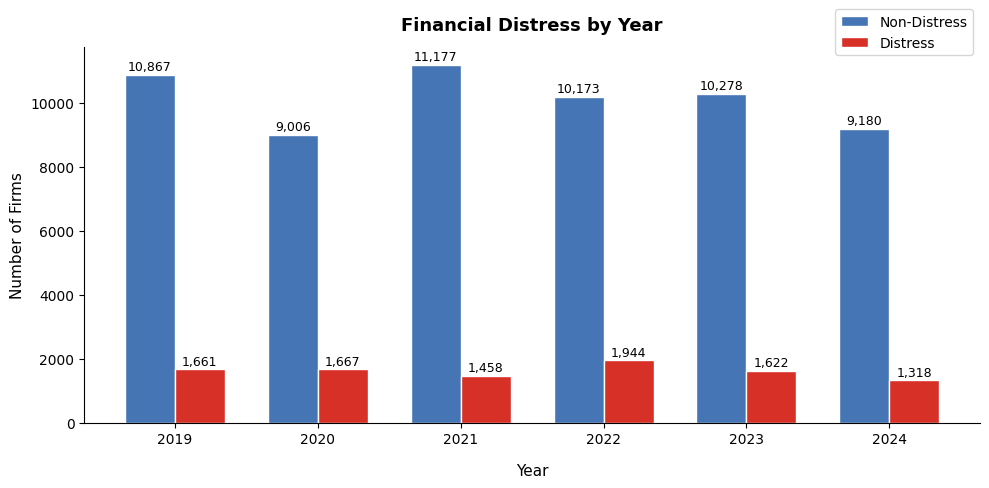

In [1629]:
yearly = (
    ana.groupby('Year')['Financial_Distress']
    .agg(Distress=lambda x: (x==1).sum(), Non_Distress=lambda x: (x==0).sum(),
         Total='count', Distress_pct=lambda x: (x==1).mean()*100)
    .reset_index()
)
yearly['Year'] = yearly['Year'].astype(int)

x, width = np.arange(len(yearly)), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, yearly['Non_Distress'], width, label='Non-Distress', color='#4575b4', edgecolor='white')
bars2 = ax.bar(x + width/2, yearly['Distress'],     width, label='Distress',     color='#d73027', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(yearly['Year'])
ax.set_xlabel('Year', fontsize=11, labelpad=12); ax.set_ylabel('Number of Firms', fontsize=11)
ax.set_title('Financial Distress by Year', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper right', bbox_to_anchor=(1, 1.12))
ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 1.2 Distress rate (%) by year

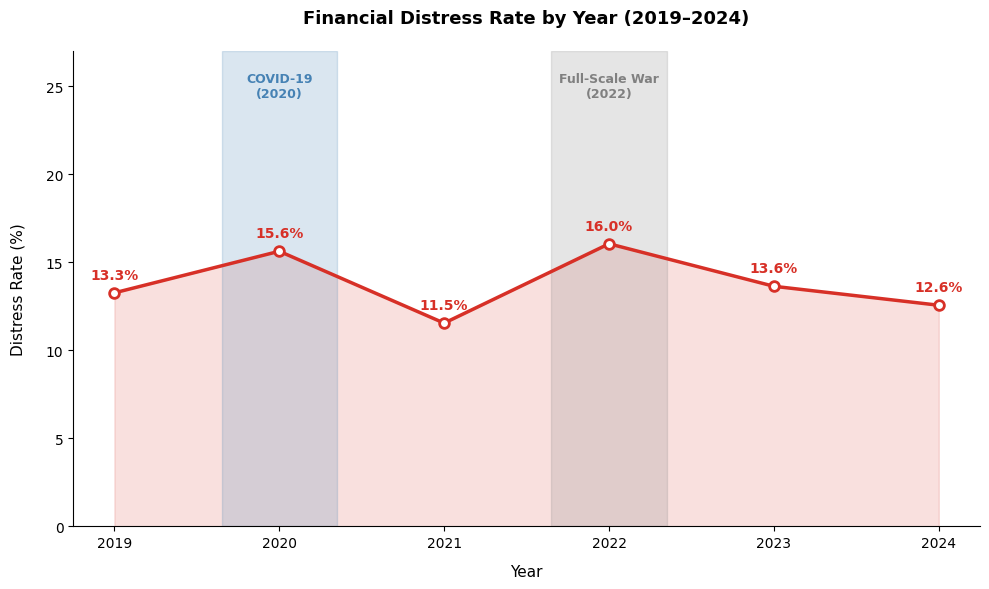

In [1630]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(yearly['Year'], yearly['Distress_pct'], alpha=0.15, color='#d73027')
ax.plot(yearly['Year'], yearly['Distress_pct'], color='#d73027', lw=2.5, marker='o',
        markersize=7, markerfacecolor='white', markeredgewidth=2)

for _, row in yearly.iterrows():
    ax.annotate(f"{row['Distress_pct']:.1f}%", xy=(row['Year'], row['Distress_pct']),
                xytext=(0, 10), textcoords='offset points', ha='center',
                fontsize=10, color='#d73027', fontweight='bold')

# Crisis period shading
ax.axvspan(2019.65, 2020.35, alpha=0.2, color='steelblue')
ax.axvspan(2021.65, 2022.35, alpha=0.2, color='gray')
ymax = yearly['Distress_pct'].max()
ax.text(2020, ymax * 1.52, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(2022, ymax * 1.52, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Distress Rate (%)', fontsize=11, labelpad=15)
ax.set_title('Financial Distress Rate by Year (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_ylim(0, 27); ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 1.3 Distress by firm status

In [1631]:
STATUS_MAP = {
    'Не перебуває в процесі припинення'        : 'Active',
    'В стані припинення'                        : 'In liquidation',
    'Припинено'                                 : 'Liquidated',
    'Порушено справу про банкрутство'           : 'Bankruptcy proceedings',
    'Порушено справу про банкрутство (санація)' : 'Bankruptcy (restructuring)',
}

status_all = (
    ana.merge(df_clean[['Firm ID', 'Firm Status (Latest)']].drop_duplicates('Firm ID'), on='Firm ID', how='left')
    .groupby('Firm Status (Latest)_y')['Firm ID'].nunique().reset_index()
    .rename(columns={'Firm Status (Latest)_y': 'Status', 'Firm ID': 'Unique Firms'})
)
status_dist = (
    ana[ana['Financial_Distress'] == 1]
    .merge(df_clean[['Firm ID', 'Firm Status (Latest)']].drop_duplicates('Firm ID'), on='Firm ID', how='left')
    .groupby('Firm Status (Latest)_y')['Firm ID'].nunique().reset_index()
    .rename(columns={'Firm Status (Latest)_y': 'Status', 'Firm ID': 'Distressed Firms'})
)
result = status_all.merge(status_dist, on='Status', how='left')
result['Healthy Firms'] = result['Unique Firms'] - result['Distressed Firms']
result['Distress (%)']  = (result['Distressed Firms'] / result['Unique Firms'] * 100).round(1)
result['Status']        = result['Status'].replace(STATUS_MAP)
result = result.sort_values('Distress (%)', ascending=False)

print("=" * 75)
print("DISTRESS BY FIRM STATUS (Unique Firms)")
print("=" * 75)
print(result.to_string(index=False))

DISTRESS BY FIRM STATUS (Unique Firms)
                    Status  Unique Firms  Distressed Firms  Healthy Firms  Distress (%)
Bankruptcy (restructuring)            36                27              9          75.0
    Bankruptcy proceedings           126                71             55          56.3
            In liquidation           799               401            398          50.2
                Liquidated           731               229            502          31.3
                    Active         16491              4412          12079          26.8


### 1.4 Distress rate (%) by industry

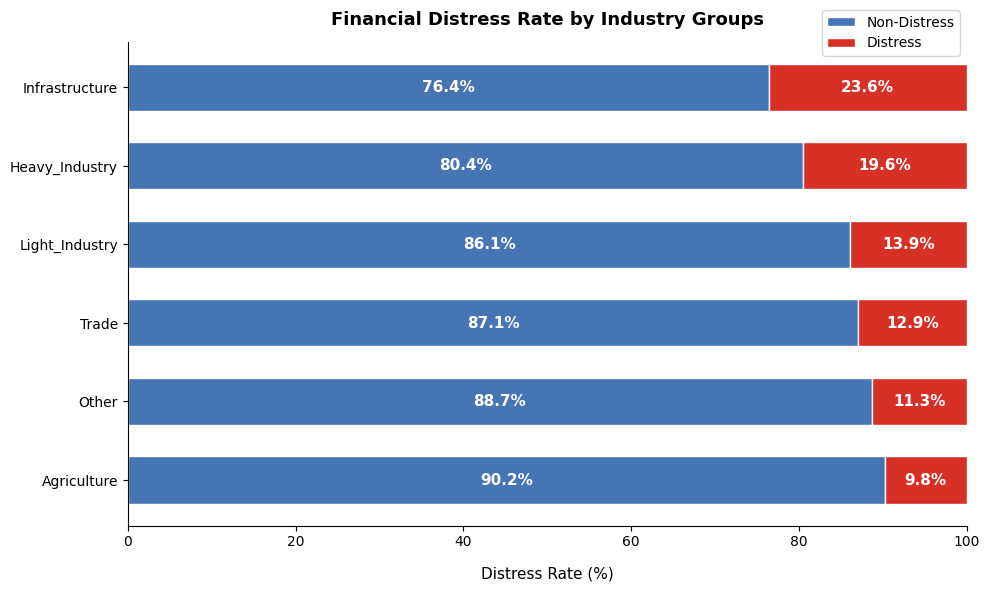

In [1632]:
industry = (
    ana.groupby('Industry_Group')['Financial_Distress']
    .agg(Distress=lambda x: (x==1).mean()*100, Non_Distress=lambda x: (x==0).mean()*100)
    .reset_index().sort_values('Distress', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars_nd = ax.barh(industry['Industry_Group'], industry['Non_Distress'],
                  color='#4575b4', edgecolor='white', label='Non-Distress', height=0.6)
bars_d  = ax.barh(industry['Industry_Group'], industry['Distress'],
                  left=industry['Non_Distress'], color='#d73027', edgecolor='white', label='Distress', height=0.6)

for bar, val in zip(bars_nd, industry['Non_Distress']):
    ax.text(val/2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            ha='center', va='center', fontsize=11, color='white', fontweight='bold')
for bar, val, left in zip(bars_d, industry['Distress'], industry['Non_Distress']):
    ax.text(left + val/2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            ha='center', va='center', fontsize=11, color='white', fontweight='bold')

ax.set_xlabel('Distress Rate (%)', fontsize=11, labelpad=12)
ax.set_title('Financial Distress Rate by Industry Groups', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.08))
ax.set_xlim(0, 100); ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 1.5 Distress rate dynamics by industry across years

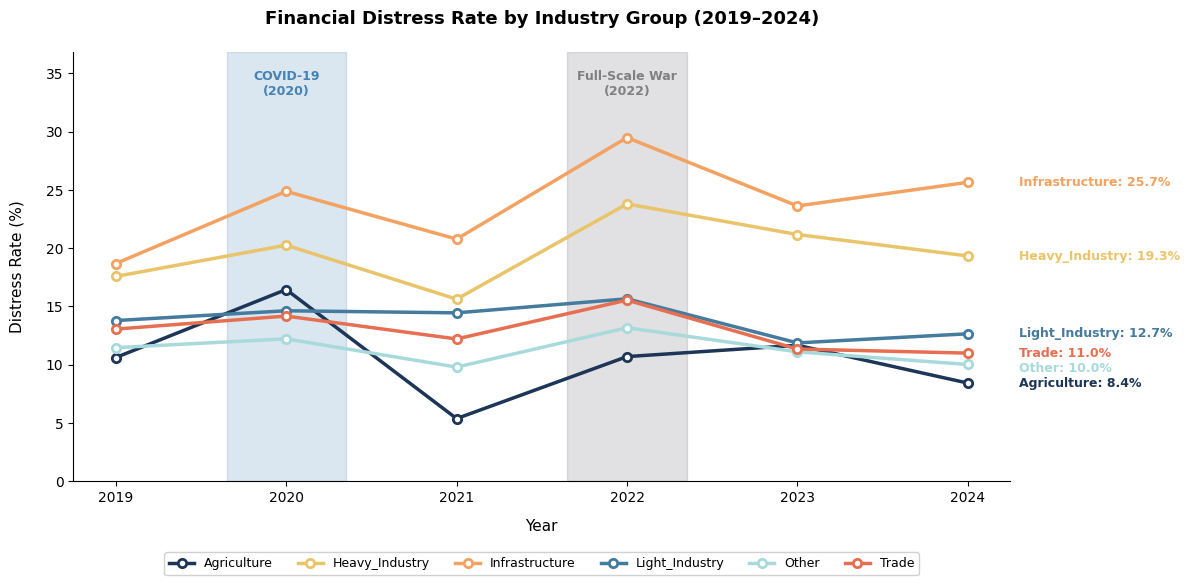

In [1633]:
distress_year = (
    ana.groupby(['Year', 'Industry_Group'])['Financial_Distress']
    .mean().mul(100).reset_index()
    .rename(columns={'Financial_Distress': 'Distress_Rate'})
)
years        = sorted(distress_year['Year'].unique())
industries   = sorted(ana['Industry_Group'].dropna().unique())

# Offsets to avoid label overlap at right edge
offsets = {
    'Trade': 0.0, 'Infrastructure': 0.0, 'Light_Industry': 0.0,
    'Heavy_Industry': 0.0, 'Other': -0.3, 'Agriculture': 0.0,
}

fig, ax = plt.subplots(figsize=(12, 6))
x_pos = {str(y): i for i, y in enumerate(years)}
y_max = distress_year['Distress_Rate'].max()
ax.set_ylim(0, y_max * 1.25)

for industry in industries:
    data = distress_year[distress_year['Industry_Group'] == industry].sort_values('Year')
    ax.plot(data['Year'].astype(str), data['Distress_Rate'],
            color=COLOR_MAP[industry], linewidth=2.5, marker='o', markersize=6,
            markerfacecolor='white', markeredgecolor=COLOR_MAP[industry], markeredgewidth=2, label=industry)
    last_val = data['Distress_Rate'].values[-1]
    ax.text(len(years) - 0.7, last_val + offsets.get(industry, 0),
            f'{industry}: {last_val:.1f}%', va='center', ha='left',
            fontsize=9, color=COLOR_MAP[industry], fontweight='bold')

ax.axvspan(x_pos['2019'] + 0.65, x_pos['2020'] + 0.35, alpha=0.2, color='steelblue')
ax.axvspan(x_pos['2021'] + 0.65, x_pos['2022'] + 0.35, alpha=0.2, color='#6d6875')
ax.text(x_pos['2020'], y_max * 1.125, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos['2022'], y_max * 1.125, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Financial Distress Rate by Industry Group (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Distress Rate (%)', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False); plt.tight_layout(); plt.show()

### 1.6 Industry share among distressed firms

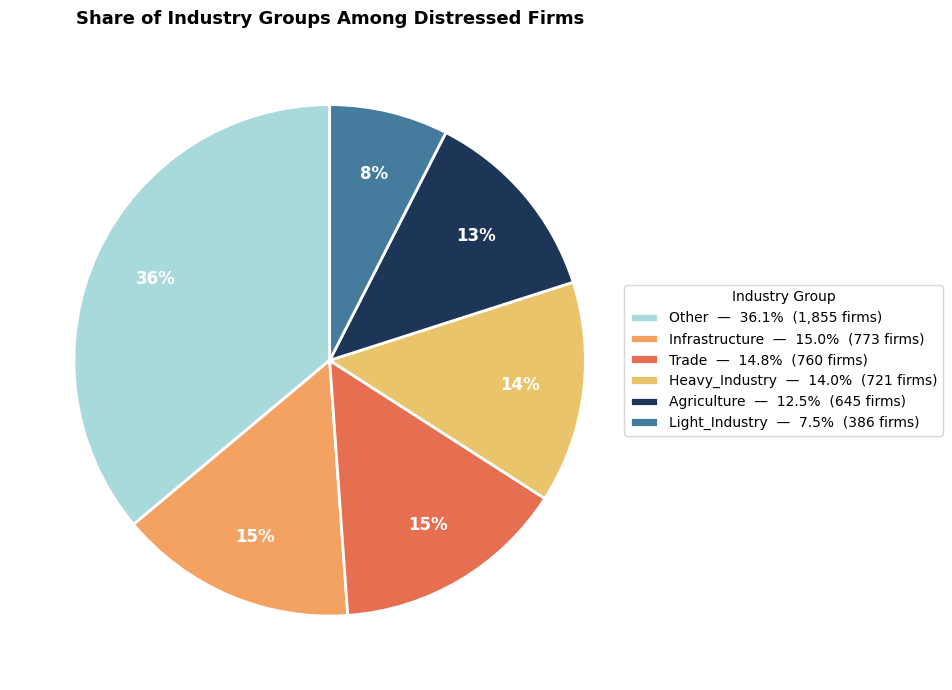

In [1634]:
distressed    = ana[ana['Financial_Distress'] == 1]
industry_dist = (distressed.groupby('Industry_Group')['Firm ID'].nunique()
                 .reset_index().rename(columns={'Firm ID': 'N_firms'})
                 .sort_values('N_firms', ascending=False))
industry_dist['Share'] = industry_dist['N_firms'] / industry_dist['N_firms'].sum() * 100

colors_pie = ['#a8dadc', '#f4a261', '#e76f51', '#e9c46a', '#1d3557', '#457b9d']
fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    industry_dist['Share'], labels=None, colors=colors_pie, autopct='%1.0f%%',
    startangle=90, pctdistance=0.75, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
legend_labels = [f"{r['Industry_Group']}  —  {r['Share']:.1f}%  ({r['N_firms']:,} firms)"
                 for _, r in industry_dist.iterrows()]
ax.legend(wedges, legend_labels, title='Industry Group', loc='center left', bbox_to_anchor=(0.95, 0.5), fontsize=10)
ax.set_title('Share of Industry Groups Among Distressed Firms', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

## **2. Distress Criteria**

In [1635]:
def plot_criterion_dual(ana, col, title, color, industries, color_map):
    """Dual chart: overall criterion rate by year (left) + by industry (right)."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    ax_left, ax_right = axes

    yearly_c = (ana.groupby('Year')[col]
                .agg(Share=lambda x: (x == 1).mean() * 100)
                .reset_index())
    yearly_c['Year'] = yearly_c['Year'].astype(int)

    ax_left.fill_between(yearly_c['Year'], yearly_c['Share'], alpha=0.15, color=color)
    ax_left.plot(yearly_c['Year'], yearly_c['Share'], color=color, lw=2.5, marker='o',
                 markersize=7, markerfacecolor='white', markeredgewidth=2)
    for _, r in yearly_c.iterrows():
        ax_left.annotate(f"{r['Share']:.1f}%", xy=(r['Year'], r['Share']),
                         xytext=(0, 10), textcoords='offset points',
                         ha='center', fontsize=9, color=color, fontweight='bold')
    ax_left.set_title(f'Share of Firms with {title} (2019–2024)', fontsize=13, fontweight='bold', pad=20)
    ax_left.set_xlabel('Year', fontsize=11, labelpad=10)
    ax_left.set_ylabel('Share (%)', fontsize=11, labelpad=15)
    ax_left.spines[['top', 'right']].set_visible(False)
    ax_left.grid(False)

    for industry in industries:
        ind_data = (ana[ana['Industry_Group'] == industry]
                    .groupby('Year')[col]
                    .agg(Share=lambda x: (x == 1).mean() * 100)
                    .reset_index())
        ind_data['Year'] = ind_data['Year'].astype(int)
        ax_right.plot(ind_data['Year'], ind_data['Share'],
                      color=color_map[industry], lw=1.8, marker='o', markersize=5,
                      label=industry, markerfacecolor='white',
                      markeredgecolor=color_map[industry], markeredgewidth=2)

    ax_right.set_title(f'{title} Rate by Industry Group (2019–2024)', fontsize=13, fontweight='bold', pad=20)
    ax_right.set_xlabel('Year', fontsize=11, labelpad=10)
    ax_right.set_ylabel('Share (%)', fontsize=11, labelpad=15)
    ax_right.legend(loc='upper center', bbox_to_anchor=(0.5, -0.17), fontsize=9, ncol=6, framealpha=0.9)
    ax_right.spines[['top', 'right']].set_visible(False)
    ax_right.grid(False)
    plt.tight_layout()
    plt.show()

### 2.1 Negative EBITDA dynamics by year and industry groups

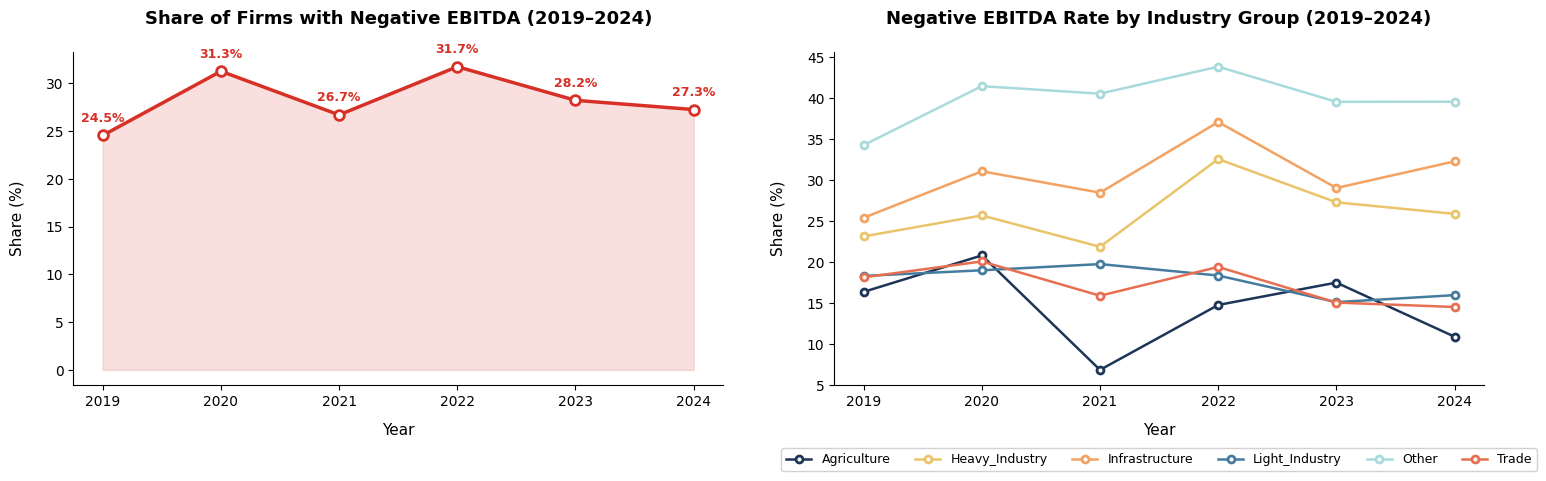

In [1636]:
plot_criterion_dual(ana, 'Distress_EBITDA', 'Negative EBITDA', '#d73027', INDUSTRIES, COLOR_MAP)

### 2.2 Revenue decline dynamics by year and industry groups

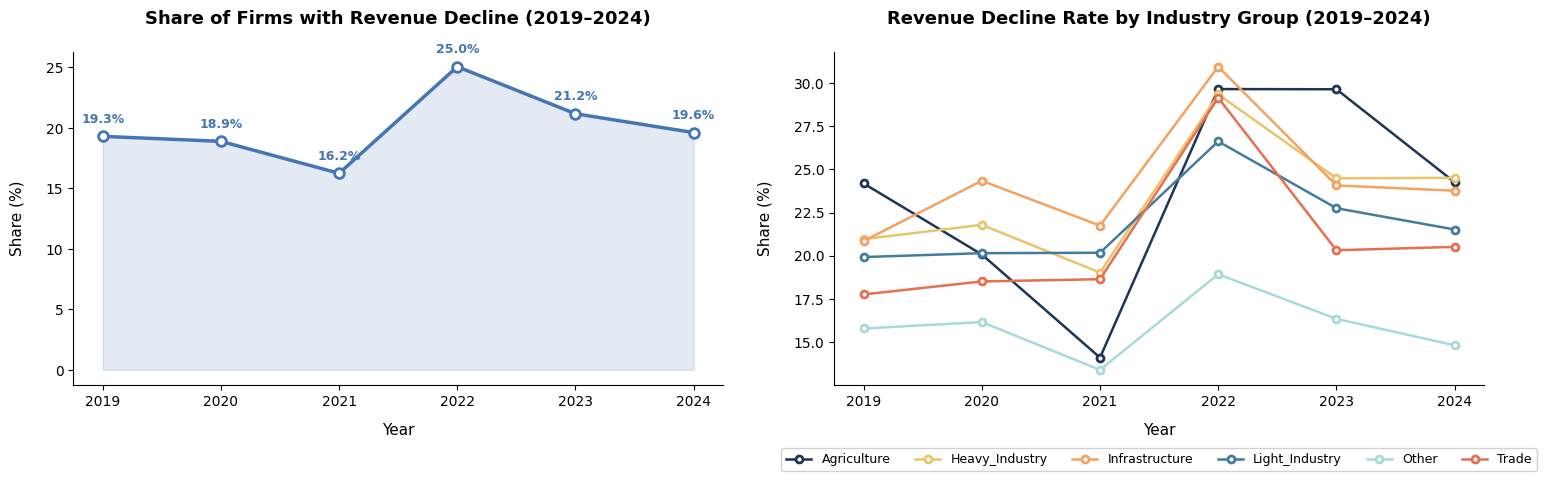

In [1637]:
plot_criterion_dual(ana, 'Distress_Revenue_Growth', 'Revenue Decline', '#4575b4', INDUSTRIES, COLOR_MAP)

### 2.3 Negative equity dynamics by year and by industry groups

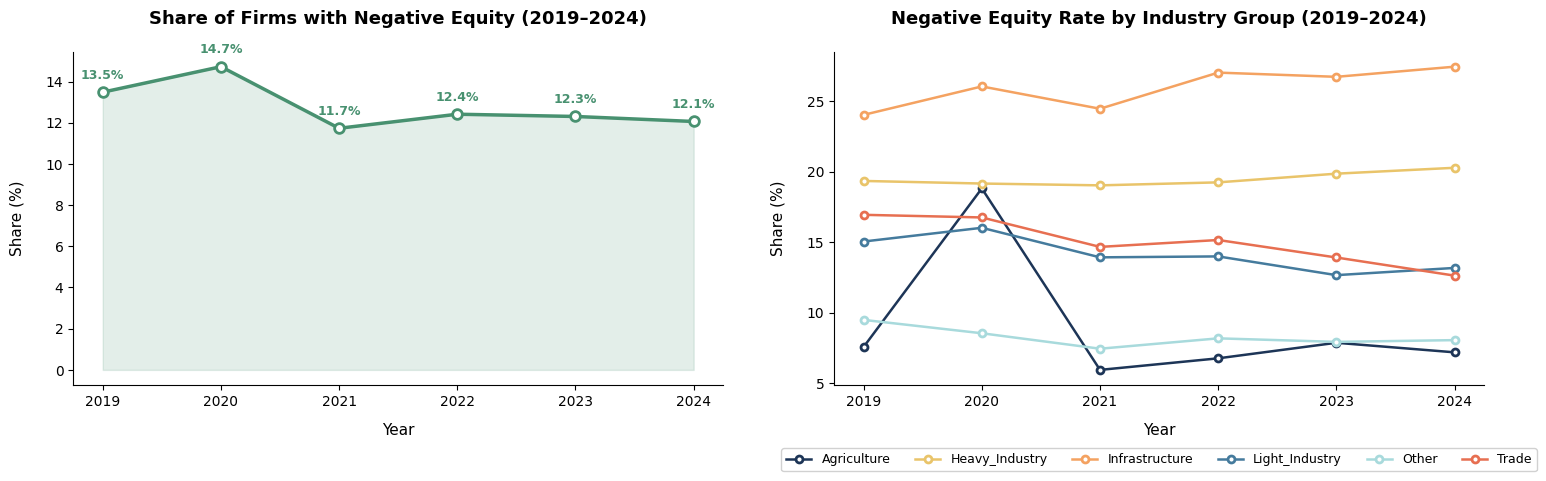

In [1638]:
plot_criterion_dual(ana, 'Distress_Equity', 'Negative Equity', '#489170', INDUSTRIES, COLOR_MAP)

### 2.4 Distress score distribution

In [1639]:
score_labels = ['0 — Healthy', '1 — At risk', '2 — Distress', '3 — Severe']

score_dist = ana['Distress_Score'].value_counts().sort_index().reset_index()
score_dist.columns = ['Score', 'N']
score_dist['Share'] = score_dist['N'] / score_dist['N'].sum() * 100

print("DISTRESS SCORE DISTRIBUTION")
print("=" * 45)
print(f"  Total observations : {score_dist['N'].sum():,}")
print()
print(f"  {'Score':<20} {'N':>8}  {'Share':>8}")
print(f"  {'-'*38}")
for _, row in score_dist.iterrows():
    label = score_labels[int(row['Score'])]
    print(f"  {label:<20} {int(row['N']):>8,}  {row['Share']:>7.1f}%")
print()
distress_n = score_dist[score_dist['Score'] >= 2]['N'].sum()
healthy_n  = score_dist[score_dist['Score'] == 0]['N'].sum()

DISTRESS SCORE DISTRIBUTION
  Total observations : 70,351

  Score                       N     Share
  --------------------------------------
  0 — Healthy            38,728     55.0%
  1 — At risk            21,953     31.2%
  2 — Distress            8,042     11.4%
  3 — Severe              1,628      2.3%



### 2.5 Distress score by industry

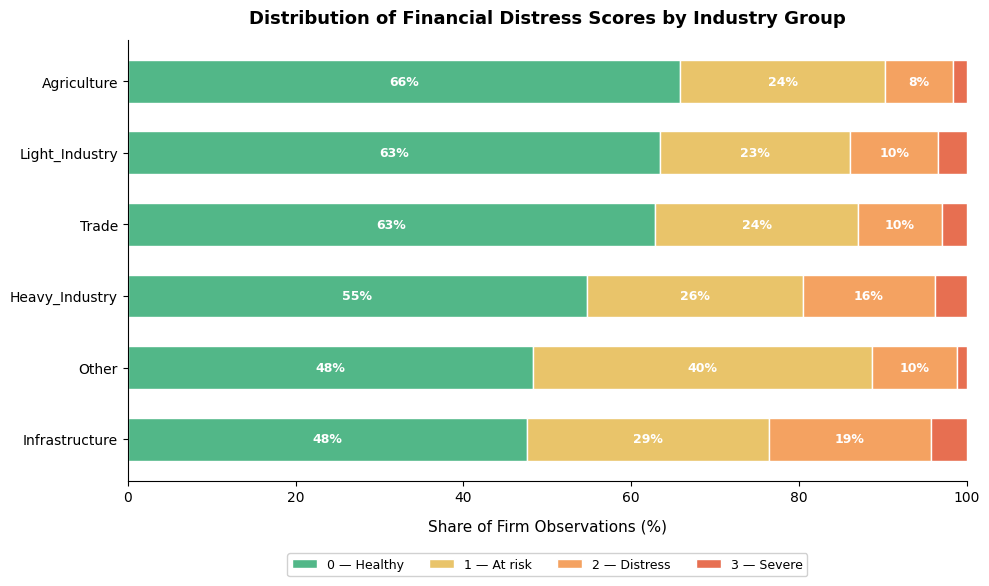

In [1640]:
score_colors = ['#52b788', '#e9c46a', '#f4a261', '#e76f51']

industry_score = (
    ana.groupby(['Industry_Group', 'Distress_Score']).size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
    .sort_values(0, ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(industry_score))
for i, (score, color) in enumerate(zip([0, 1, 2, 3], score_colors)):
    if score in industry_score.columns:
        vals = industry_score[score].values
        bars = ax.barh(industry_score.index, vals, left=bottom,
                       color=color, edgecolor='white', height=0.6, label=score_labels[i])
        for j, (bar, val) in enumerate(zip(bars, vals)):
            if val > 5:
                ax.text(bottom[j] + val/2, bar.get_y() + bar.get_height()/2,
                        f'{val:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += vals

ax.set_xlabel('Share of Firm Observations (%)', fontsize=11, labelpad=10)
ax.set_title('Distribution of Financial Distress Scores by Industry Group', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 100)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=4, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 2.6 Conditional probabilities between distress criteria

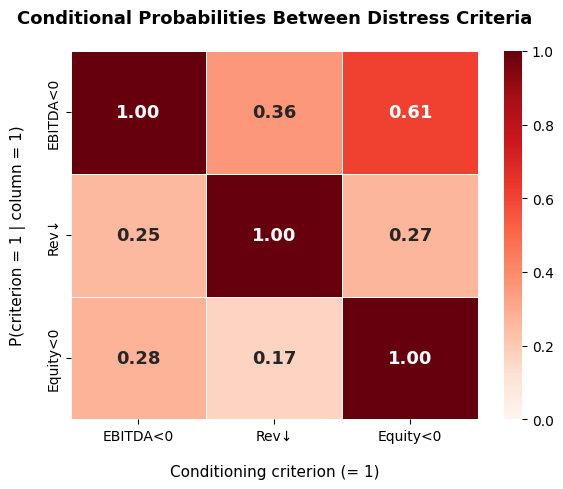

In [1641]:
crit_cols  = ['Distress_EBITDA', 'Distress_Revenue_Growth', 'Distress_Equity']
crit_names = ['EBITDA<0', 'Rev↓', 'Equity<0']

# P(row=1 | col=1)
cond_prob = np.zeros((3, 3))
for i, col_a in enumerate(crit_cols):
    for j, col_b in enumerate(crit_cols):
        mask = ana[col_b] == 1
        cond_prob[i, j] = (ana.loc[mask, col_a] == 1).mean()

cond_df = pd.DataFrame(cond_prob, index=crit_names, columns=crit_names)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cond_df, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 13, 'weight': 'bold'})
ax.set_xlabel('Conditioning criterion (= 1)', fontsize=11, labelpad=15)
ax.set_ylabel('P(criterion = 1 | column = 1)', fontsize=11, labelpad=15)
ax.set_title('Conditional Probabilities Between Distress Criteria', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()

## **3. Distress Persistence**

### 3.1 Transition matrix

In [1642]:
def build_pairs(df):
    """Build consecutive year pairs for transition analysis."""
    df_s = df.sort_values(['Firm ID', 'Year'])
    df_s['Distress_t1'] = df_s.groupby('Firm ID')['Financial_Distress'].shift(-1)
    df_s['Year_next']   = df_s.groupby('Firm ID')['Year'].shift(-1)
    pairs = df_s[(df_s['Distress_t1'].notna()) & (df_s['Year_next'] - df_s['Year'] == 1)].copy()
    pairs = pairs.rename(columns={'Financial_Distress': 'Distress_t'})
    return pairs[['Firm ID', 'Year', 'Industry_Group', 'Distress_t', 'Distress_t1']]

def boot_persistence(df_pairs, n_boot=1000, seed=42):
    """Bootstrap 95% CI for persistence rate among distressed firms."""
    np.random.seed(seed)
    rates = [resample(df_pairs)['Distress_t1'].mean() for _ in range(n_boot)]
    return np.percentile(rates, [2.5, 97.5])

pairs = build_pairs(ana)

# Overall transition matrix
tm = pd.crosstab(pairs['Distress_t'].astype(int), pairs['Distress_t1'].astype(int), normalize='index').round(3)
tm.index   = ['Healthy (t)', 'Distress (t)']
tm.columns = ['→ Healthy (t+1)', '→ Distress (t+1)']

print("TRANSITION MATRIX — OVERALL"); print("=" * 55); print(tm.to_string())
ci = boot_persistence(pairs[pairs['Distress_t'] == 1])
persist_rate = pairs[pairs['Distress_t'] == 1]['Distress_t1'].mean()
print(f"\nPersistence rate : {persist_rate:.3f}")
print(f"95% Bootstrap CI : [{ci[0]:.3f}, {ci[1]:.3f}]")

# By sub-period
print("\nPERSISTENCE RATE BY SUB-PERIOD"); print("=" * 65)
print(f"{'Sub-period':<20} {'Rate':>8}  {'CI Lower':>10}  {'CI Upper':>10}  {'N distress':>12}")
print("-" * 65)
for label, mask in [('Pre-COVID (2019)',       pairs['Year'] == 2019),
                     ('COVID-19 (2020)',        pairs['Year'] == 2020),
                     ('Full-scale War (2022)',  pairs['Year'] == 2022)]:
    sub = pairs[mask & (pairs['Distress_t'] == 1)]
    if len(sub) > 10:
        rate = sub['Distress_t1'].mean(); ci = boot_persistence(sub)
        print(f"{label:<20} {rate:>8.3f}  {ci[0]:>10.3f}  {ci[1]:>10.3f}  {len(sub):>12,}")

# By industry
print("\nPERSISTENCE RATE BY INDUSTRY"); print("=" * 65)
print(f"{'Industry':<25} {'Rate':>8}  {'CI Lower':>10}  {'CI Upper':>10}  {'N distress':>12}")
print("-" * 65)
ind_results = []
for industry in sorted(pairs['Industry_Group'].unique()):
    sub = pairs[(pairs['Industry_Group'] == industry) & (pairs['Distress_t'] == 1)]
    if len(sub) > 10:
        rate = sub['Distress_t1'].mean(); ci = boot_persistence(sub)
        ind_results.append({'Industry': industry, 'Rate': rate, 'CI_lower': ci[0], 'CI_upper': ci[1], 'N': len(sub)})
for r in sorted(ind_results, key=lambda x: -x['Rate']):
    print(f"{r['Industry']:<25} {r['Rate']:>8.3f}  {r['CI_lower']:>10.3f}  {r['CI_upper']:>10.3f}  {r['N']:>12,}")

TRANSITION MATRIX — OVERALL
              → Healthy (t+1)  → Distress (t+1)
Healthy (t)             0.913             0.087
Distress (t)            0.440             0.560

Persistence rate : 0.560
95% Bootstrap CI : [0.547, 0.572]

PERSISTENCE RATE BY SUB-PERIOD
Sub-period               Rate    CI Lower    CI Upper    N distress
-----------------------------------------------------------------
Pre-COVID (2019)        0.629       0.604       0.657         1,130
COVID-19 (2020)         0.537       0.506       0.564         1,187
Full-scale War (2022)    0.503       0.478       0.526         1,645

PERSISTENCE RATE BY INDUSTRY
Industry                      Rate    CI Lower    CI Upper    N distress
-----------------------------------------------------------------
Infrastructure               0.670       0.642       0.694         1,172
Heavy_Industry               0.634       0.607       0.662         1,146
Light_Industry               0.625       0.584       0.667           507
Trade    

### 3.2 Distress episode duration

In [1643]:
df_s = ana.sort_values(['Firm ID', 'Year']).copy()

# Identify distinct distress spells per firm
df_s['distress_spell'] = (
    df_s.groupby('Firm ID')['Financial_Distress']
    .transform(lambda x: (x != x.shift()).cumsum())
)

spell_len = (
    df_s[df_s['Financial_Distress'] == 1]
    .groupby(['Firm ID', 'distress_spell', 'Industry_Group'])
    .agg(spell_duration=('Year', 'count'))
    .reset_index()
)

spell_len['Duration_Group'] = spell_len['spell_duration'].apply(
    lambda x: '1 year' if x == 1 else ('2 years' if x == 2 else '3+ years')
)

overall = (
    spell_len['Duration_Group']
    .value_counts()
    .reindex(['1 year', '2 years', '3+ years'])
    .reset_index()
)
overall.columns = ['Duration', 'N_spells']
overall['Share'] = overall['N_spells'] / overall['N_spells'].sum() * 100

print("DISTRESS EPISODE DURATION — OVERALL")
print("=" * 50)
print(f"  Total episodes : {len(spell_len):,}")
print()
print(f"  {'Duration':<12} {'N episodes':>10}  {'Share':>8}")
print(f"  {'-'*32}")
for _, r in overall.iterrows():
    print(f"  {r['Duration']:<12} {int(r['N_spells']):>10,}  {r['Share']:>7.1f}%")

print()
print(f"  Transient (1 year)  : {overall.loc[0, 'Share']:.1f}%")
print(f"  Moderate  (2 years) : {overall.loc[1, 'Share']:.1f}%")
print(f"  Chronic   (3+ years): {overall.loc[2, 'Share']:.1f}%")

print()
print("DISTRESS EPISODE DURATION BY INDUSTRY")
print("=" * 65)

ind_spells = (
    spell_len.groupby(['Industry_Group', 'Duration_Group'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['1 year', '2 years', '3+ years'], fill_value=0)
)

ind_pct = ind_spells.div(ind_spells.sum(axis=1), axis=0) * 100
ind_pct['Chronic_Share'] = ind_pct['3+ years']
ind_pct = ind_pct.sort_values('Chronic_Share', ascending=False)

print(f"  {'Industry':<25} {'1 year':>8}  {'2 years':>8}  {'3+ years':>8}  {'N episodes':>10}")
print(f"  {'-'*60}")
for ind in ind_pct.index:
    n = ind_spells.loc[ind].sum()
    print(f"  {ind:<25} "
          f"{ind_pct.loc[ind, '1 year']:>7.1f}%  "
          f"{ind_pct.loc[ind, '2 years']:>7.1f}%  "
          f"{ind_pct.loc[ind, '3+ years']:>7.1f}%  "
          f"{int(n):>10,}")

DISTRESS EPISODE DURATION — OVERALL
  Total episodes : 5,959

  Duration     N episodes     Share
  --------------------------------
  1 year            3,958     66.4%
  2 years           1,116     18.7%
  3+ years            885     14.9%

  Transient (1 year)  : 66.4%
  Moderate  (2 years) : 18.7%
  Chronic   (3+ years): 14.9%

DISTRESS EPISODE DURATION BY INDUSTRY
  Industry                    1 year   2 years  3+ years  N episodes
  ------------------------------------------------------------
  Infrastructure               57.5%     20.8%     21.7%         908
  Heavy_Industry               58.2%     20.7%     21.1%         866
  Light_Industry               59.2%     23.2%     17.5%         439
  Trade                        62.9%     21.4%     15.8%         843
  Other                        72.2%     17.3%     10.4%       2,147
  Agriculture                  78.2%     12.4%      9.4%         756


## **4. Profitability**

### 4.1 Median ROA dynamics

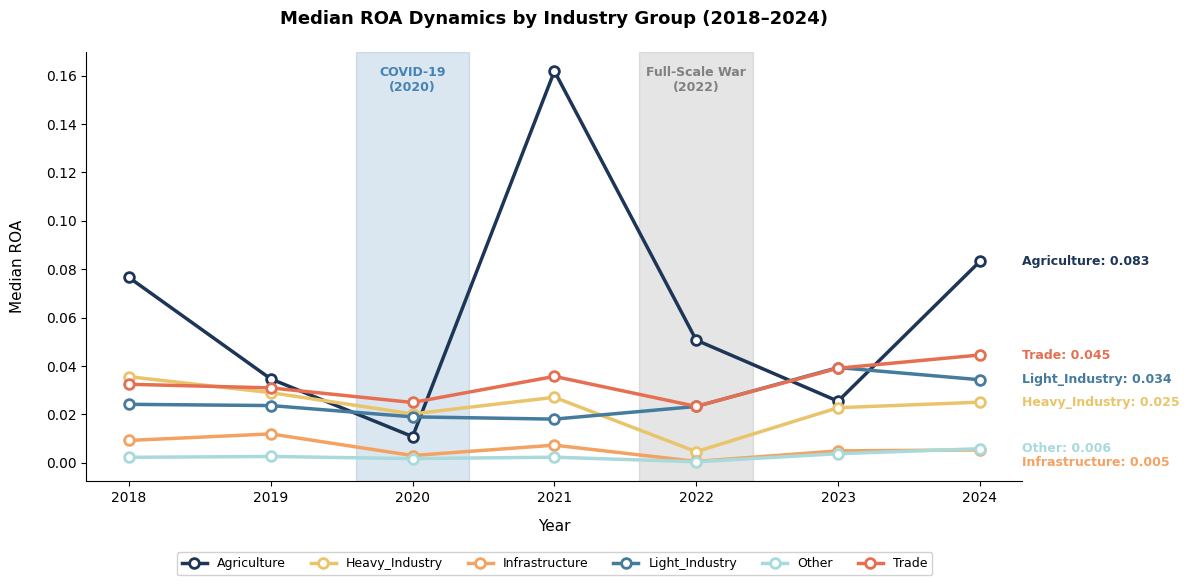

In [1644]:
industries = sorted(df_clean['Industry_Group'].dropna().unique())
years      = list(df_clean['Year'].sort_values().unique())
x_pos      = {str(y): i for i, y in enumerate(years)}

y_max = df_clean.groupby(['Industry_Group', 'Year'])['ROA'].median().max()
offsets = {'Infrastructure': -0.005, 'Other': 0.00}

fig, ax = plt.subplots(figsize=(12, 6))
for industry in industries:
    color  = COLOR_MAP[industry]
    yearly = df_clean[df_clean['Industry_Group'] == industry].groupby('Year')['ROA'].median()
    ax.plot(yearly.index.astype(str), yearly.values, color=color, linewidth=2.5, marker='o',
            markersize=7, markerfacecolor='white', markeredgecolor=color, markeredgewidth=2, label=industry)
    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(yearly) - 0.7, last_y, f'{industry}: {yearly.values[-1]:.3f}',
            va='center', ha='left', fontsize=9, color=color, fontweight='bold')

ax.axvspan(x_pos['2020'] - 0.4, x_pos['2020'] + 0.4, alpha=0.2, color='steelblue')
ax.axvspan(x_pos['2022'] - 0.4, x_pos['2022'] + 0.4, alpha=0.2, color='gray')
ax.text(x_pos['2020'], y_max * 0.95, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos['2022'], y_max * 0.95, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Median ROA Dynamics by Industry Group (2018–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Median ROA', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.tick_params(axis='y', labelsize=10); ax.grid(False)
plt.tight_layout(); plt.show()

### 4.2 Distress and non-distress analysis

In [1645]:
metrics = {
    'ROA'         : 'ROA',
    'EBIT/Assets' : 'EBIT_Assets',
    'Gross Margin': 'Gross_Margin',
}

print("=" * 65); print("PROFITABILITY — Distress vs Non-Distress"); print("=" * 65)
results = [mw_stats(ana, col, name) for name, col in metrics.items()]
results_df = pd.DataFrame(results).sort_values('Effect size', ascending=False)

PROFITABILITY — Distress vs Non-Distress

ROA:
  Median Non-Distress :   0.0253
  Median Distress     :  -0.1009
  Difference          :   0.1263
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.7654  large

EBIT/Assets:
  Median Non-Distress :   0.0332
  Median Distress     :  -0.1020
  Difference          :   0.1353
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.7837  large

Gross Margin:
  Median Non-Distress :   0.2000
  Median Distress     :   0.1011
  Difference          :   0.0989
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.2244  small


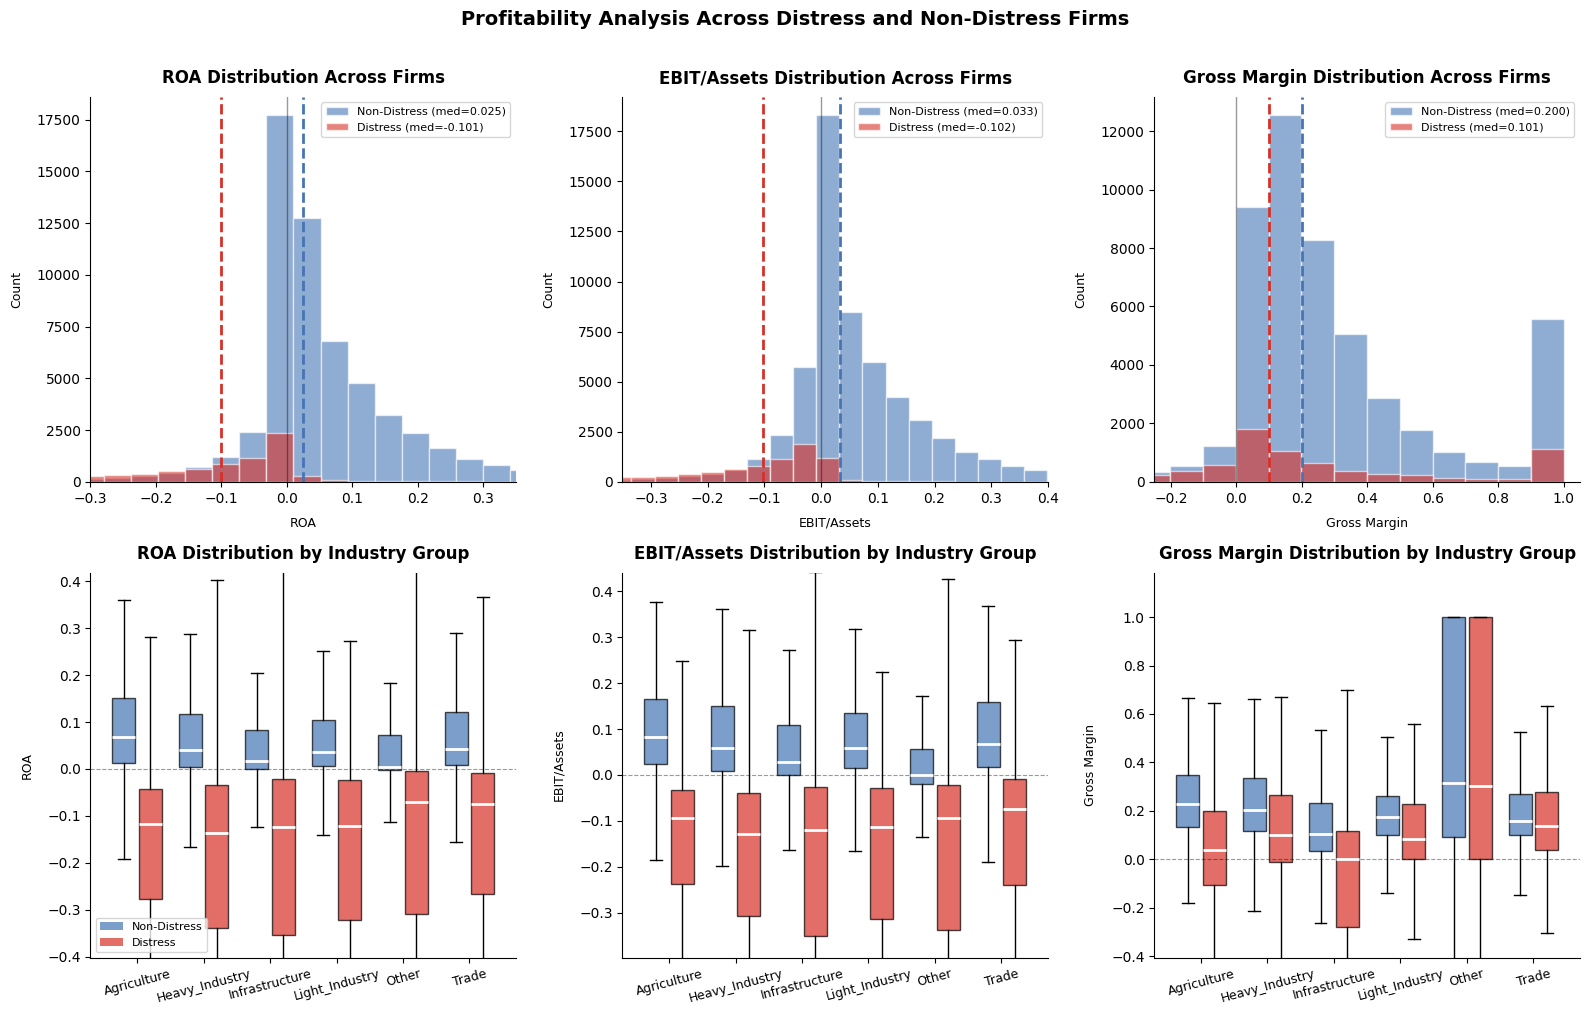

In [1646]:
colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}

xlim_map = {
    'ROA'         : (-0.30, 0.35),
    'EBIT/Assets' : (-0.35, 0.40),
    'Gross Margin': (-0.25, 1.05),
}
industries = sorted(ana['Industry_Group'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, (name, col) in enumerate(metrics.items()):

    # ── Top row: distributions ──
    ax_hist = axes[0, col_idx]
    for group in [0, 1]:
        data = ana[ana['Financial_Distress'] == group][col].dropna()
        ax_hist.hist(data, bins=60, color=colors_group[group], alpha=0.6,
                     edgecolor='white', label=f"{labels_group[group]} (med={data.median():.3f})")
        ax_hist.axvline(data.median(), color=colors_group[group], linewidth=2, linestyle='--')
    ax_hist.axvline(0, color='black', linewidth=1.0, linestyle='-', alpha=0.4)
    ax_hist.set_xlim(*xlim_map[name])
    ax_hist.set_title(f'{name} Distribution Across Firms', fontsize=12, fontweight='bold', pad=10)
    ax_hist.set_xlabel(name, fontsize=9, labelpad=8); ax_hist.set_ylabel('Count', fontsize=9, labelpad=10)
    ax_hist.legend(fontsize=8, framealpha=0.8)
    ax_hist.spines[['top', 'right']].set_visible(False); ax_hist.grid(False)

    # ── Bottom row: boxplot by industry ──
    ax_box = axes[1, col_idx]
    positions_0 = np.arange(len(industries)) - 0.2
    positions_1 = np.arange(len(industries)) + 0.2
    data_0 = [ana[(ana['Industry_Group']==ind)&(ana['Financial_Distress']==0)][col].dropna() for ind in industries]
    data_1 = [ana[(ana['Industry_Group']==ind)&(ana['Financial_Distress']==1)][col].dropna() for ind in industries]
    bp0 = ax_box.boxplot(data_0, positions=positions_0, widths=0.35, patch_artist=True,
                         showfliers=False, medianprops=dict(color='white', linewidth=2))
    bp1 = ax_box.boxplot(data_1, positions=positions_1, widths=0.35, patch_artist=True,
                         showfliers=False, medianprops=dict(color='white', linewidth=2))
    for patch in bp0['boxes']: patch.set_facecolor(colors_group[0]); patch.set_alpha(0.7)
    for patch in bp1['boxes']: patch.set_facecolor(colors_group[1]); patch.set_alpha(0.7)
    # Y-axis scale P5–P95
    all_data = ana[col].dropna()
    p5, p95  = all_data.quantile(0.05), all_data.quantile(0.95)
    margin   = (p95 - p5) * 0.15
    ax_box.set_ylim(p5 - margin, p95 + margin)
    ax_box.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax_box.set_xticks(np.arange(len(industries)))
    ax_box.set_xticklabels(industries, rotation=15, fontsize=9)
    ax_box.set_title(f'{name} Distribution by Industry Group', fontsize=12, fontweight='bold', pad=10)
    ax_box.set_ylabel(name, fontsize=9, labelpad=10)
    ax_box.spines[['top', 'right']].set_visible(False); ax_box.grid(False)
    if col_idx == 0:
        legend_elements = [Patch(facecolor=colors_group[g], alpha=0.7, label=labels_group[g]) for g in [0, 1]]
        ax_box.legend(handles=legend_elements, fontsize=8, loc='lower left')

fig.suptitle('Profitability Analysis Across Distress and Non-Distress Firms', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## **5. Liquidity**

### 5.1 Median Current Ratio dynamics

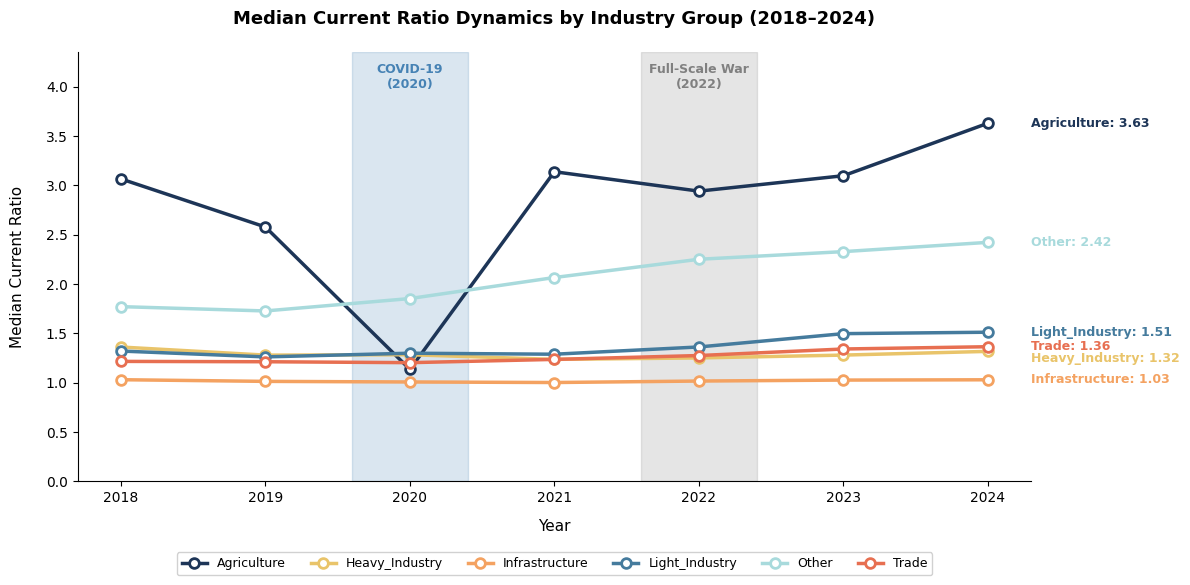

In [1647]:
industries = sorted(df_clean['Industry_Group'].dropna().unique())
years      = list(df_clean['Year'].sort_values().unique())
x_pos      = {str(y): i for i, y in enumerate(years)}

y_max = df_clean.groupby(['Industry_Group', 'Year'])['Current_Ratio'].median().max()
offsets = {'Heavy_Industry': -0.07}

fig, ax = plt.subplots(figsize=(12, 6))
for industry in industries:
    color  = COLOR_MAP[industry]
    yearly = df_clean[df_clean['Industry_Group'] == industry].groupby('Year')['Current_Ratio'].median()
    ax.plot(yearly.index.astype(str), yearly.values, color=color, linewidth=2.5, marker='o',
            markersize=7, markerfacecolor='white', markeredgecolor=color, markeredgewidth=2, label=industry)
    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(yearly) - 0.7, last_y, f'{industry}: {yearly.values[-1]:.2f}',
            va='center', ha='left', fontsize=9, color=color, fontweight='bold')

ax.axvspan(x_pos['2020'] - 0.4, x_pos['2020'] + 0.4, alpha=0.2, color='steelblue')
ax.axvspan(x_pos['2022'] - 0.4, x_pos['2022'] + 0.4, alpha=0.2, color='gray')
ax.text(x_pos['2020'], y_max * 1.1, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos['2022'], y_max * 1.1, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_ylim(0, y_max * 1.2)
ax.set_title('Median Current Ratio Dynamics by Industry Group (2018–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Median Current Ratio', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.tick_params(axis='y', labelsize=10); ax.grid(False)
plt.tight_layout(); plt.show()

### 5.2 Distress and non-distress analysis

In [1648]:
metrics = {
    'Current Ratio': 'Current_Ratio',
    'Quick Ratio'  : 'Quick_Ratio',
    'WC/Assets'    : 'WC_Assets',
}

print("=" * 65); print("LIQUIDITY — Distress vs Non-Distress"); print("=" * 65)
results = [mw_stats(ana, col, name) for name, col in metrics.items()]
results_df = pd.DataFrame(results).sort_values('Effect size', ascending=False)

LIQUIDITY — Distress vs Non-Distress

Current Ratio:
  Median Non-Distress :   1.7860
  Median Distress     :   0.6389
  Difference          :   1.1471
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.5274  large

Quick Ratio:
  Median Non-Distress :   1.1423
  Median Distress     :   0.4047
  Difference          :   0.7376
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.4394  medium

WC/Assets:
  Median Non-Distress :   0.2419
  Median Distress     :  -0.3271
  Difference          :   0.5690
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.5556  large


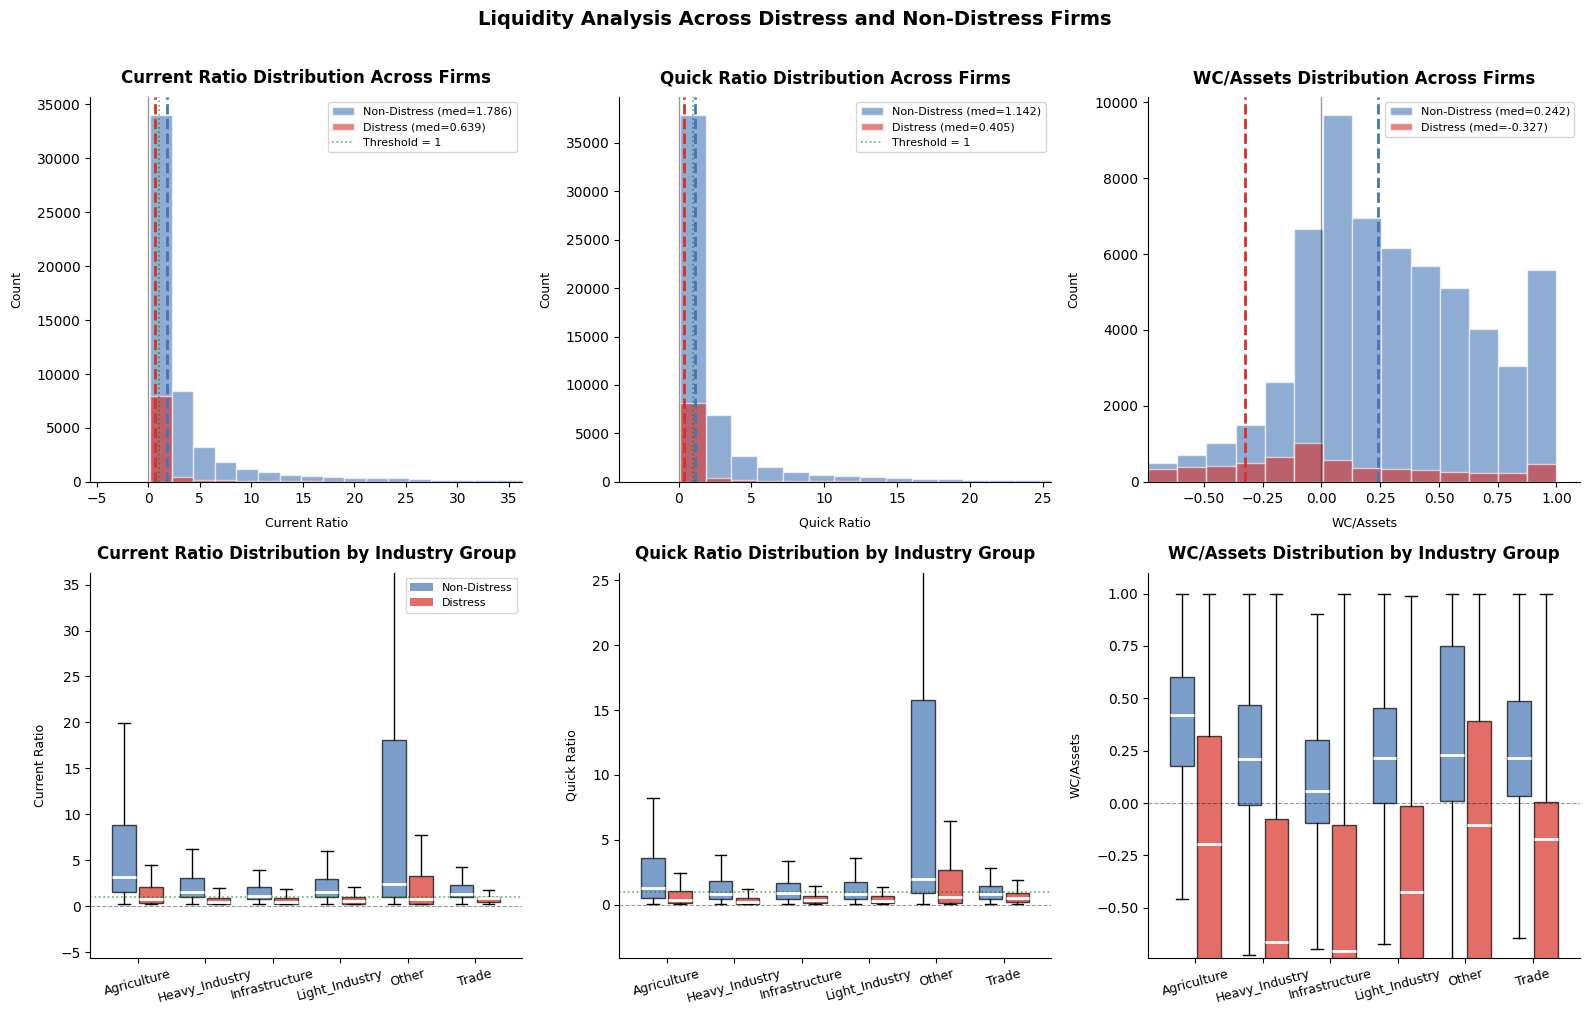

In [1649]:
colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}

industries = sorted(ana['Industry_Group'].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, (name, col) in enumerate(metrics.items()):

    # ── Top row: distributions — xlim auto P10/P90 ──
    ax_hist = axes[0, col_idx]
    all_data_hist = ana[col].dropna()
    p10_h, p90_h = all_data_hist.quantile(0.10), all_data_hist.quantile(0.90)
    margin_h = (p90_h - p10_h) * 0.2

    for group in [0, 1]:
        data = ana[ana['Financial_Distress'] == group][col].dropna()
        ax_hist.hist(data, bins=60, color=colors_group[group], alpha=0.6,
                     edgecolor='white', label=f"{labels_group[group]} (med={data.median():.3f})")
        ax_hist.axvline(data.median(), color=colors_group[group], linewidth=2, linestyle='--')
    ax_hist.axvline(0, color='black', linewidth=1.0, linestyle='-', alpha=0.4)
    if name in ['Current Ratio', 'Quick Ratio']:
        ax_hist.axvline(1, color='green', linewidth=1.2, linestyle=':', alpha=0.6, label='Threshold = 1')
    ax_hist.set_xlim(p10_h - margin_h, p90_h + margin_h)
    ax_hist.set_title(f'{name} Distribution Across Firms', fontsize=12, fontweight='bold', pad=10)
    ax_hist.set_xlabel(name, fontsize=9, labelpad=8); ax_hist.set_ylabel('Count', fontsize=9, labelpad=10)
    ax_hist.legend(fontsize=8, framealpha=0.8)
    ax_hist.spines[['top', 'right']].set_visible(False); ax_hist.grid(False)

    # ── Bottom row: boxplot by industry — ylim P10/P90 ──
    ax_box = axes[1, col_idx]
    positions_0 = np.arange(len(industries)) - 0.2
    positions_1 = np.arange(len(industries)) + 0.2
    data_0 = [ana[(ana['Industry_Group']==ind)&(ana['Financial_Distress']==0)][col].dropna() for ind in industries]
    data_1 = [ana[(ana['Industry_Group']==ind)&(ana['Financial_Distress']==1)][col].dropna() for ind in industries]
    bp0 = ax_box.boxplot(data_0, positions=positions_0, widths=0.35, patch_artist=True,
                         showfliers=False, medianprops=dict(color='white', linewidth=2))
    bp1 = ax_box.boxplot(data_1, positions=positions_1, widths=0.35, patch_artist=True,
                         showfliers=False, medianprops=dict(color='white', linewidth=2))
    for patch in bp0['boxes']: patch.set_facecolor(colors_group[0]); patch.set_alpha(0.7)
    for patch in bp1['boxes']: patch.set_facecolor(colors_group[1]); patch.set_alpha(0.7)
    all_data = ana[col].dropna()
    p10, p90 = all_data.quantile(0.10), all_data.quantile(0.90)
    margin   = (p90 - p10) * 0.2
    ax_box.set_ylim(p10 - margin, p90 + margin)
    ax_box.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    if name in ['Current Ratio', 'Quick Ratio']:
        ax_box.axhline(y=1, color='green', linewidth=1.2, linestyle=':', alpha=0.6, label='Threshold = 1')
    ax_box.set_xticks(np.arange(len(industries)))
    ax_box.set_xticklabels(industries, rotation=15, fontsize=9)
    ax_box.set_title(f'{name} Distribution by Industry Group', fontsize=12, fontweight='bold', pad=10)
    ax_box.set_ylabel(name, fontsize=9, labelpad=10)
    ax_box.spines[['top', 'right']].set_visible(False); ax_box.grid(False)
    if col_idx == 0:
        legend_elements = [Patch(facecolor=colors_group[g], alpha=0.7, label=labels_group[g]) for g in [0, 1]]
        ax_box.legend(handles=legend_elements, fontsize=8)

fig.suptitle('Liquidity Analysis Across Distress and Non-Distress Firms', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## **6. Leverage and Debt Structure**

### 6.1 Total Debt distribution

In [1650]:
# Total Debt: breakdown between zero and positive values
data  = df_clean['Total Debt'].dropna()
total = len(data)
zero  = (data == 0).sum()
pos   = (data > 0).sum()

print("=" * 50)
print("TOTAL DEBT — DISTRIBUTION OF VALUES")
print("=" * 50)
print(f"  Zero     (= 0) : {zero:>8,}  ({zero/total*100:.1f}%)")
print(f"  Positive (> 0) : {pos:>8,}  ({pos/total*100:.1f}%)")
print(f"  Total          : {total:>8,}")

TOTAL DEBT — DISTRIBUTION OF VALUES
  Zero     (= 0) :   62,870  (77.4%)
  Positive (> 0) :   18,399  (22.6%)
  Total          :   81,269


### 6.2 Total Debt presence by industry

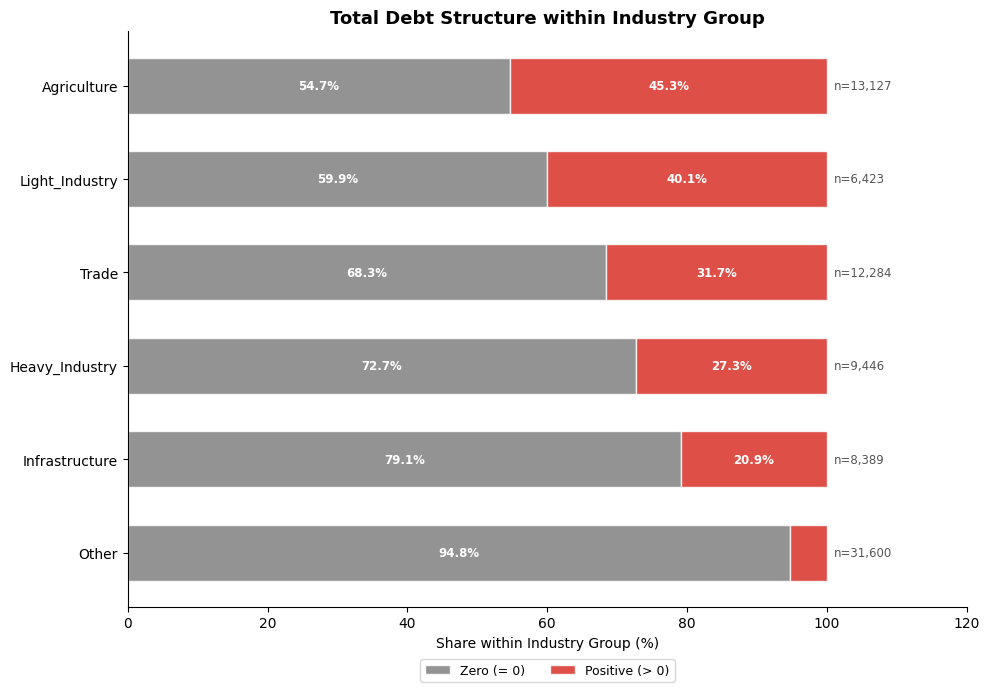

In [1651]:
fig, ax = plt.subplots(figsize=(10, 7))
labels  = ['Zero (= 0)', 'Positive (> 0)']
colors  = ['gray', '#d73027']

industry_pct = df_clean.groupby('Industry_Group').apply(lambda x: pd.Series({
    labels[0]: (x['Total Debt'] == 0).sum() / len(x) * 100,
    labels[1]: (x['Total Debt'] > 0).sum() / len(x) * 100,
    'N': len(x)
})).sort_values(labels[1], ascending=True)

y_pos = np.arange(len(industry_pct))
left  = np.zeros(len(industry_pct))
for category, color in zip(labels, colors):
    vals = industry_pct[category].values
    bars = ax.barh(y_pos, vals, left=left, color=color, edgecolor='white',
                   alpha=0.85, label=category, height=0.6)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 8:
            ax.text(left[i] + val/2, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', ha='center', fontsize=8.5, color='white', fontweight='bold')
    left += vals

for i, (idx, row_data) in enumerate(industry_pct.iterrows()):
    ax.text(101, y_pos[i], f'n={int(row_data["N"]):,}', va='center', ha='left', fontsize=8.5, color='#555555')

ax.set_yticks(y_pos); ax.set_yticklabels(industry_pct.index, fontsize=10)
ax.set_title('Total Debt Structure within Industry Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Share within Industry Group (%)', fontsize=10)
ax.spines[['top', 'right']].set_visible(False); ax.grid(False); ax.set_xlim(0, 120)
ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.tight_layout(); plt.show()

### 6.3 Bank loan structure by industry group

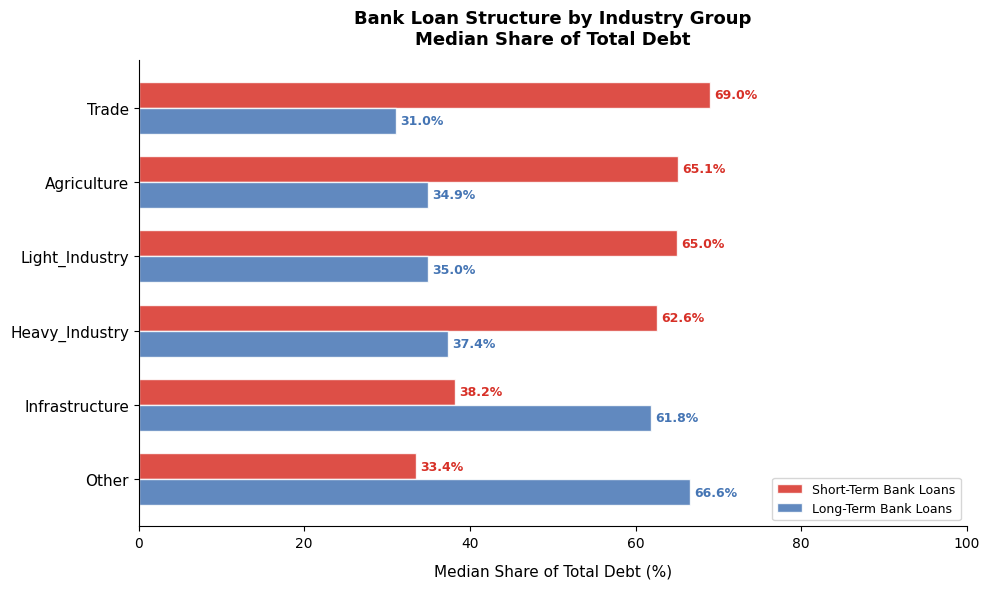

In [1652]:
df_debt = df_clean[df_clean['Total Debt'] > 0].copy()

debt_structure = (
    df_debt.groupby(['Industry_Group', 'Year'])
    .agg(
        Total_Debt = ('Total Debt',            'sum'),
        ST_Bank    = ('Short-Term Bank Loans', 'sum'),
        LT_Bank    = ('Long-Term Bank Loans',  'sum'),
    )
    .reset_index()
)
debt_structure['ST_Share'] = debt_structure['ST_Bank'] / debt_structure['Total_Debt'] * 100
debt_structure['LT_Share'] = debt_structure['LT_Bank'] / debt_structure['Total_Debt'] * 100

median_structure = (
    debt_structure.groupby('Industry_Group')
    .agg(ST_Median=('ST_Share', 'median'), LT_Median=('LT_Share', 'median'))
    .reset_index()
    .sort_values('ST_Median', ascending=True)
)

industries_sorted = median_structure['Industry_Group'].tolist()
x, width = np.arange(len(industries_sorted)), 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_st = ax.barh(x + width/2, median_structure['ST_Median'], width,
                  color='#d73027', edgecolor='white', label='Short-Term Bank Loans', alpha=0.85)
bars_lt = ax.barh(x - width/2, median_structure['LT_Median'], width,
                  color='#4575b4', edgecolor='white', label='Long-Term Bank Loans', alpha=0.85)

for bar, val in zip(bars_st, median_structure['ST_Median']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9, color='#d73027', fontweight='bold')
for bar, val in zip(bars_lt, median_structure['LT_Median']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9, color='#4575b4', fontweight='bold')

ax.set_yticks(x); ax.set_yticklabels(industries_sorted, fontsize=11)
ax.set_xlabel('Median Share of Total Debt (%)', fontsize=11, labelpad=10)
ax.set_title('Bank Loan Structure by Industry Group\nMedian Share of Total Debt',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 100)
ax.legend(fontsize=9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 6.4 Bank debt prevalence and distress rate

In [1653]:
df_clean['Bank_Debt_Assets'] = (df_clean['Long-Term Bank Loans'] + df_clean['Short-Term Bank Loans']) / df_clean['Total Assets']
ana['Bank_Debt_Assets']      = (ana['Long-Term Bank Loans']      + ana['Short-Term Bank Loans'])      / ana['Total Assets']
df_debt_ana = ana[ana['Bank_Debt_Assets'] > 0].copy()

print("=" * 65); print("BANK DEBT PREVALENCE AND STRUCTURE"); print("=" * 65)
print(f"\nWith bank debt : {(df_clean['Bank_Debt_Assets']>0).sum():,}  ({(df_clean['Bank_Debt_Assets']>0).mean()*100:.1f}%)")
print(f"Distress rate WITH debt   : {df_debt_ana['Financial_Distress'].mean()*100:.1f}%")
print(f"Distress rate WITHOUT debt: {ana[ana['Bank_Debt_Assets']==0]['Financial_Distress'].mean()*100:.1f}%")

BANK DEBT PREVALENCE AND STRUCTURE

With bank debt : 18,399  (22.6%)
Distress rate WITH debt   : 8.6%
Distress rate WITHOUT debt: 15.2%


### 6.5 Distress rate by bank debt status

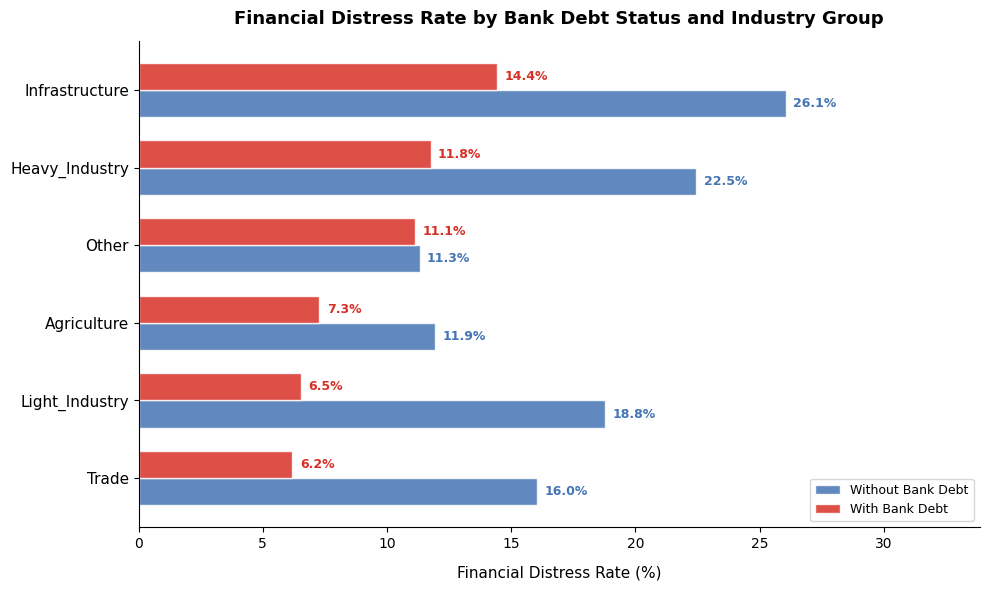

In [1654]:
distress_comparison = ana.groupby('Industry_Group').apply(lambda x: pd.Series({
    'With Debt'   : x[x['Bank_Debt_Assets'] > 0]['Financial_Distress'].mean() * 100,
    'Without Debt': x[x['Bank_Debt_Assets'] == 0]['Financial_Distress'].mean() * 100,
})).sort_values('With Debt', ascending=True)

y, width = np.arange(len(distress_comparison)), 0.35
fig, ax  = plt.subplots(figsize=(10, 6))

bars1 = ax.barh(y - width/2, distress_comparison['Without Debt'], height=width,
                color='#4575b4', edgecolor='white', label='Without Bank Debt', alpha=0.85)
bars2 = ax.barh(y + width/2, distress_comparison['With Debt'],    height=width,
                color='#d73027', edgecolor='white', label='With Bank Debt', alpha=0.85)

for bar, val in zip(bars1, distress_comparison['Without Debt']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', ha='left', fontsize=9, color='#4575b4', fontweight='bold')
for bar, val in zip(bars2, distress_comparison['With Debt']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', ha='left', fontsize=9, color='#d73027', fontweight='bold')

ax.set_yticks(y); ax.set_yticklabels(distress_comparison.index, fontsize=11)
ax.set_title('Financial Distress Rate by Bank Debt Status and Industry Group', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Financial Distress Rate (%)', fontsize=11, labelpad=10)
ax.set_xlim(0, distress_comparison.max().max() * 1.3)
ax.spines[['top', 'right']].set_visible(False); ax.legend(fontsize=9, loc='lower right'); ax.grid(False)
plt.tight_layout(); plt.show()

### 6.6 Long-term and Short-term liabilities by industry

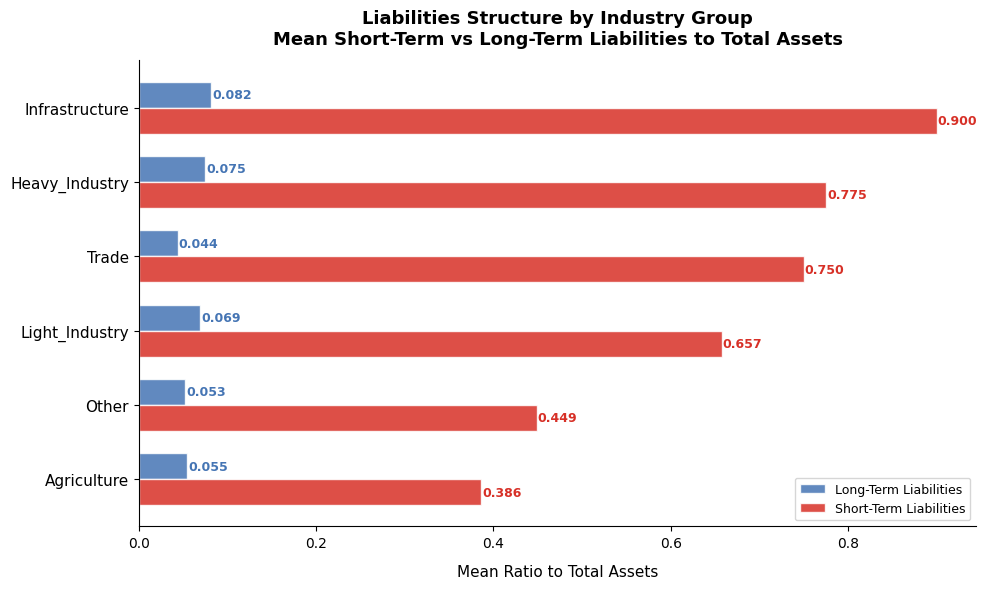

In [1655]:
df_liab = df_clean[df_clean['Total Liabilities'] > 0].copy()
lt_st = (df_liab.groupby('Industry_Group')
         .agg(LT_Liab=('LT_Liab_Assets', 'mean'), ST_Liab=('ST_Liab_Assets', 'mean'))
         .reset_index().sort_values('ST_Liab', ascending=True))

industries_lt = lt_st['Industry_Group'].tolist()
x, width = np.arange(len(industries_lt)), 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_lt = ax.barh(x + width/2, lt_st['LT_Liab'], width, color='#4575b4', edgecolor='white',
                  label='Long-Term Liabilities', alpha=0.85)
bars_st = ax.barh(x - width/2, lt_st['ST_Liab'], width, color='#d73027', edgecolor='white',
                  label='Short-Term Liabilities', alpha=0.85)

for bar, val in zip(bars_lt, lt_st['LT_Liab']):
    if val > 0.001:
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
                va='center', ha='left', fontsize=9, color='#4575b4', fontweight='bold')
for bar, val in zip(bars_st, lt_st['ST_Liab']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha='left', fontsize=9, color='#d73027', fontweight='bold')

ax.set_yticks(x); ax.set_yticklabels(industries_lt, fontsize=11)
ax.set_xlabel('Mean Ratio to Total Assets', fontsize=11, labelpad=10)
ax.set_title('Liabilities Structure by Industry Group\nMean Short-Term vs Long-Term Liabilities to Total Assets',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 6.7 Distress and non-distress analysis

In [1656]:
metrics = {
    'TL/Assets'      : 'TL_Assets',
    'AP/Assets'      : 'AP_Assets',
    'LT Liab/Assets' : 'LT_Liab_Assets',
    'ST Liab/Assets' : 'ST_Liab_Assets',
}

print("=" * 65); print("LEVERAGE — Distress vs Non-Distress"); print("=" * 65)
results = [mw_stats(ana, col, name) for name, col in metrics.items()]
results_df = pd.DataFrame(results).sort_values('Effect size', ascending=False)

LEVERAGE — Distress vs Non-Distress

TL/Assets:
  Median Non-Distress :   0.3621
  Median Distress     :   1.1316
  Difference          :  -0.7695
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.6052  large

AP/Assets:
  Median Non-Distress :   0.0284
  Median Distress     :   0.0956
  Difference          :  -0.0672
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.2322  small

LT Liab/Assets:
  Median Non-Distress :   0.0000
  Median Distress     :   0.0000
  Difference          :   0.0000
  Mann-Whitney p      : 0.0204  *
  Effect size (r)     : 0.0125  small

ST Liab/Assets:
  Median Non-Distress :   0.2917
  Median Distress     :   1.0598
  Difference          :  -0.7681
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.5612  large


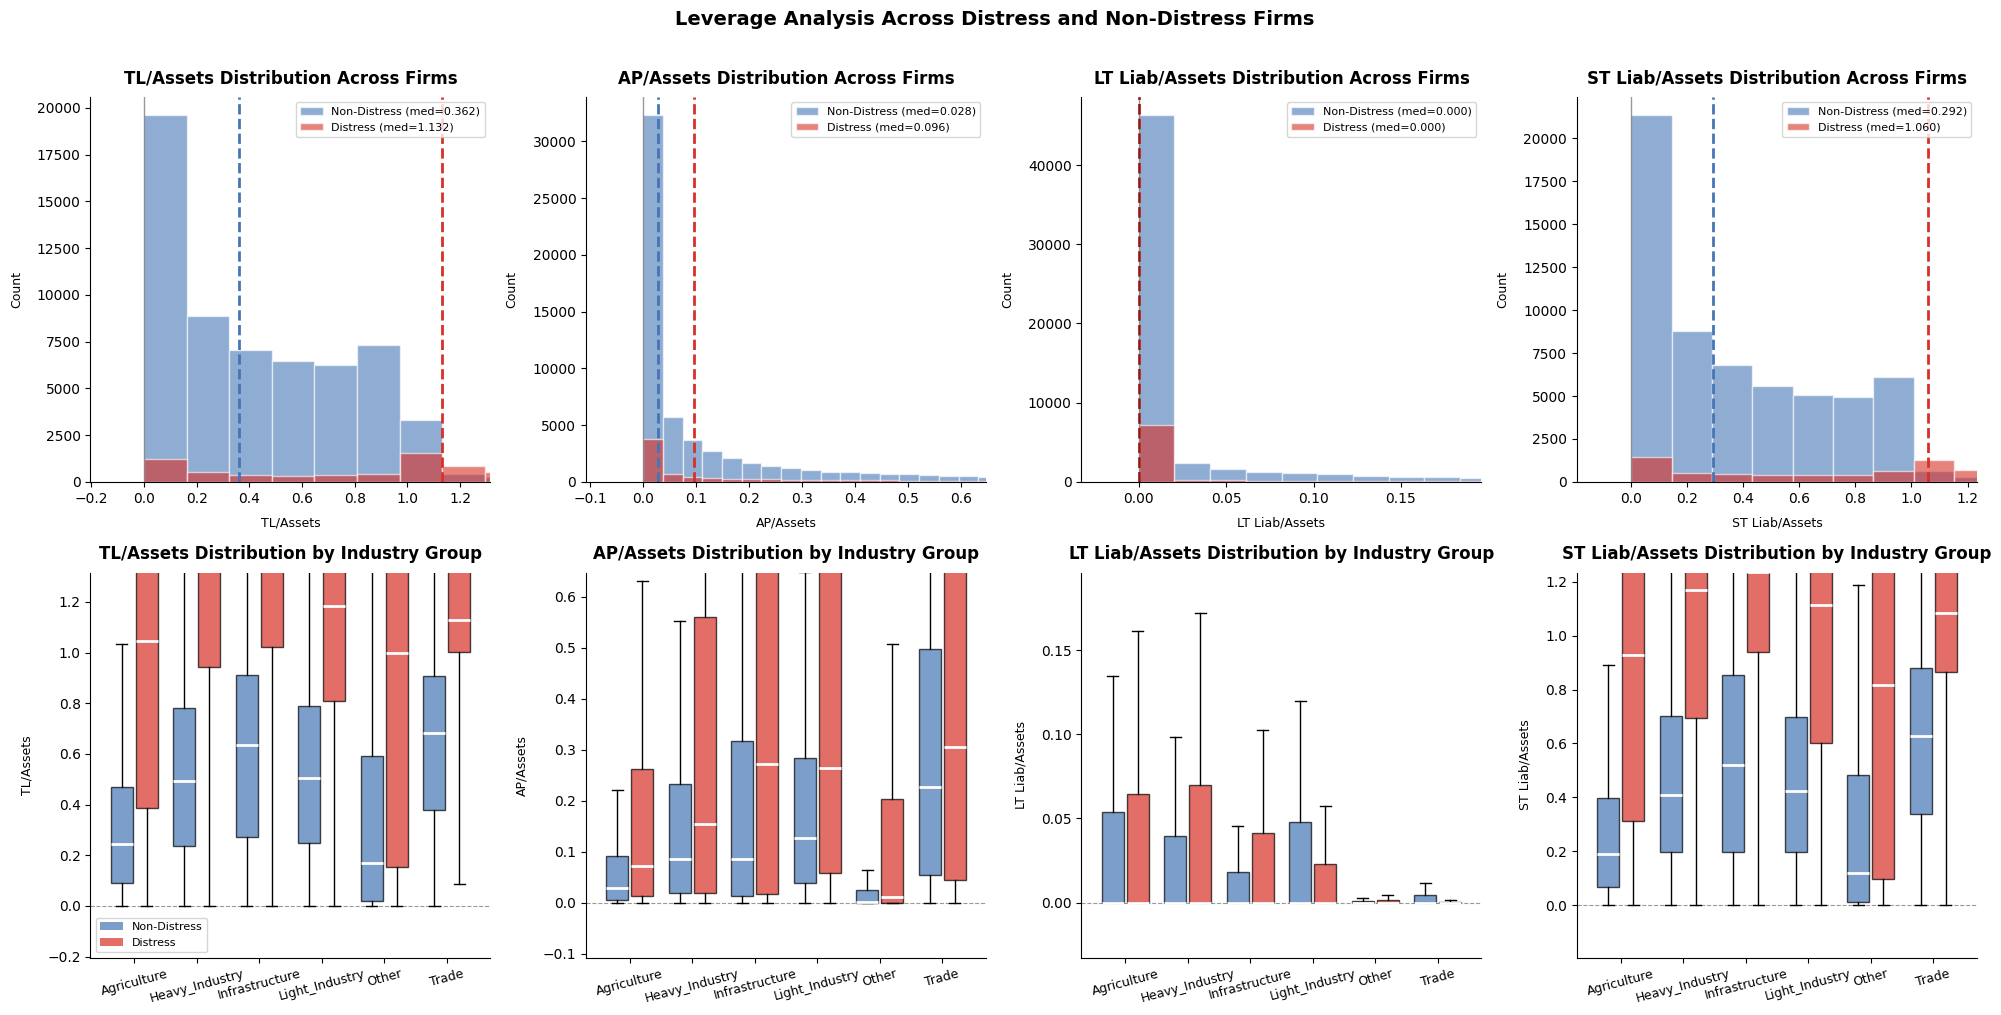

In [1657]:
colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}

industries = sorted(ana['Industry_Group'].dropna().unique())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col_idx, (name, col) in enumerate(metrics.items()):

    # ── Top row: distributions — xlim auto P10/P90 ──
    ax_hist = axes[0, col_idx]
    all_data_hist = ana[col].dropna()
    p10_h, p90_h  = all_data_hist.quantile(0.10), all_data_hist.quantile(0.90)
    margin_h = (p90_h - p10_h) * 0.2

    for group in [0, 1]:
        data = ana[ana['Financial_Distress'] == group][col].dropna()
        ax_hist.hist(data, bins=50, color=colors_group[group], alpha=0.6,
                     edgecolor='white', label=f"{labels_group[group]} (med={data.median():.3f})")
        ax_hist.axvline(data.median(), color=colors_group[group], linewidth=2, linestyle='--')
    ax_hist.axvline(0, color='black', linewidth=1.0, linestyle='-', alpha=0.4)
    ax_hist.set_xlim(p10_h - margin_h, p90_h + margin_h)
    ax_hist.set_title(f'{name} Distribution Across Firms', fontsize=12, fontweight='bold', pad=10)
    ax_hist.set_xlabel(name, fontsize=9, labelpad=8); ax_hist.set_ylabel('Count', fontsize=9, labelpad=10)
    ax_hist.legend(fontsize=8, framealpha=0.8)
    ax_hist.spines[['top', 'right']].set_visible(False); ax_hist.grid(False)

    # ── Bottom row: boxplot by industry — ylim P10/P90 ──
    ax_box = axes[1, col_idx]
    positions_0 = np.arange(len(industries)) - 0.2
    positions_1 = np.arange(len(industries)) + 0.2
    data_0 = [ana[(ana['Industry_Group']==ind)&(ana['Financial_Distress']==0)][col].dropna() for ind in industries]
    data_1 = [ana[(ana['Industry_Group']==ind)&(ana['Financial_Distress']==1)][col].dropna() for ind in industries]
    bp0 = ax_box.boxplot(data_0, positions=positions_0, widths=0.35, patch_artist=True,
                         showfliers=False, medianprops=dict(color='white', linewidth=2))
    bp1 = ax_box.boxplot(data_1, positions=positions_1, widths=0.35, patch_artist=True,
                         showfliers=False, medianprops=dict(color='white', linewidth=2))
    for patch in bp0['boxes']: patch.set_facecolor(colors_group[0]); patch.set_alpha(0.7)
    for patch in bp1['boxes']: patch.set_facecolor(colors_group[1]); patch.set_alpha(0.7)
    all_data = ana[col].dropna()
    p10, p90 = all_data.quantile(0.10), all_data.quantile(0.90)
    margin   = (p90 - p10) * 0.2
    ax_box.set_ylim(p10 - margin, p90 + margin)
    ax_box.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax_box.set_xticks(np.arange(len(industries)))
    ax_box.set_xticklabels(industries, rotation=15, fontsize=9)
    ax_box.set_title(f'{name} Distribution by Industry Group', fontsize=12, fontweight='bold', pad=10)
    ax_box.set_ylabel(name, fontsize=9, labelpad=10)
    ax_box.spines[['top', 'right']].set_visible(False); ax_box.grid(False)
    if col_idx == 0:
        legend_elements = [Patch(facecolor=colors_group[g], alpha=0.7, label=labels_group[g]) for g in [0, 1]]
        ax_box.legend(handles=legend_elements, fontsize=8)

fig.suptitle('Leverage Analysis Across Distress and Non-Distress Firms', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 6.8 Median AP/Assets dynamics by industry

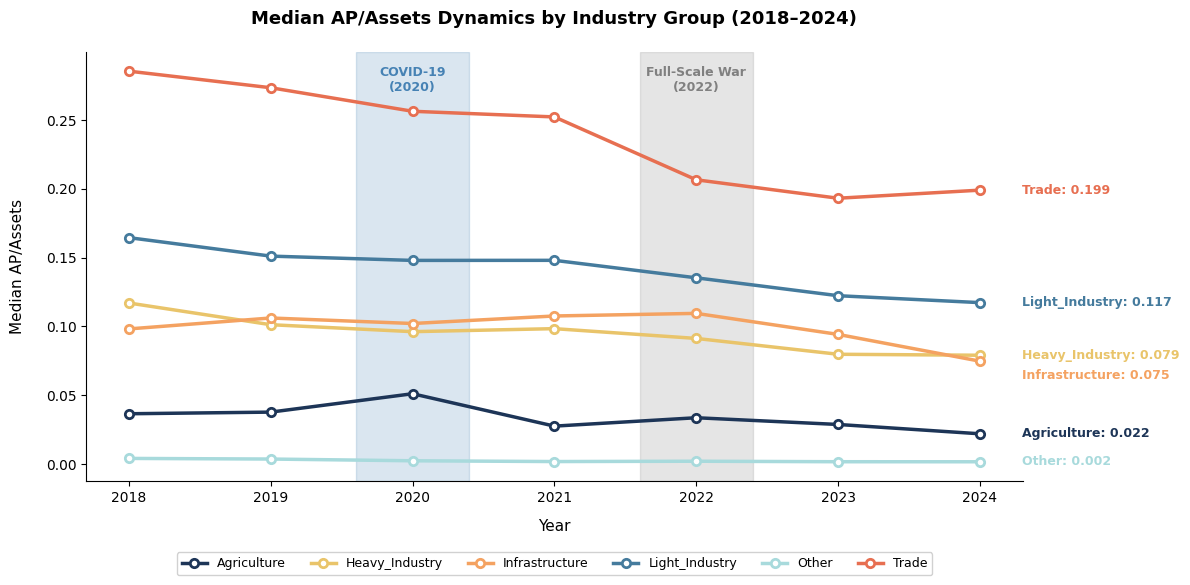

In [1658]:
industries = sorted(df_clean['Industry_Group'].dropna().unique())
years      = sorted(df_clean['Year'].unique())
x_pos_int  = {y: i for i, y in enumerate(years)}
y_max      = df_clean.groupby(['Industry_Group', 'Year'])['AP_Assets'].median().max()

offsets = {
    'Trade'          :  0.0,
    'Infrastructure' : -0.01,
    'Light_Industry' :  0.0,
    'Heavy_Industry' :  0.0,
    'Other'          :  0.0,
    'Agriculture'    :  0.0,
}

fig, ax = plt.subplots(figsize=(12, 6))
for industry in industries:
    yearly = df_clean[df_clean['Industry_Group'] == industry].groupby('Year')['AP_Assets'].median()
    ax.plot(yearly.index.astype(str), yearly.values, color=COLOR_MAP[industry], linewidth=2.5,
            marker='o', markersize=6, markerfacecolor='white',
            markeredgecolor=COLOR_MAP[industry], markeredgewidth=2, label=industry)
    ax.text(len(years) - 0.7, yearly.values[-1] + offsets.get(industry, 0),
            f'{industry}: {yearly.values[-1]:.3f}',
            va='center', ha='left', fontsize=9, color=COLOR_MAP[industry], fontweight='bold')

ax.axvspan(x_pos_int[2019] + 0.6, x_pos_int[2020] + 0.4, alpha=0.2, color='steelblue')
ax.axvspan(x_pos_int[2021] + 0.6, x_pos_int[2022] + 0.4, alpha=0.2, color='gray')
ax.text(x_pos_int[2020], y_max * 0.95, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos_int[2022], y_max * 0.95, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Median AP/Assets Dynamics by Industry Group (2018–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Median AP/Assets', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False); plt.tight_layout(); plt.show()

### 6.9 Median TL/Assets dynamics by industry

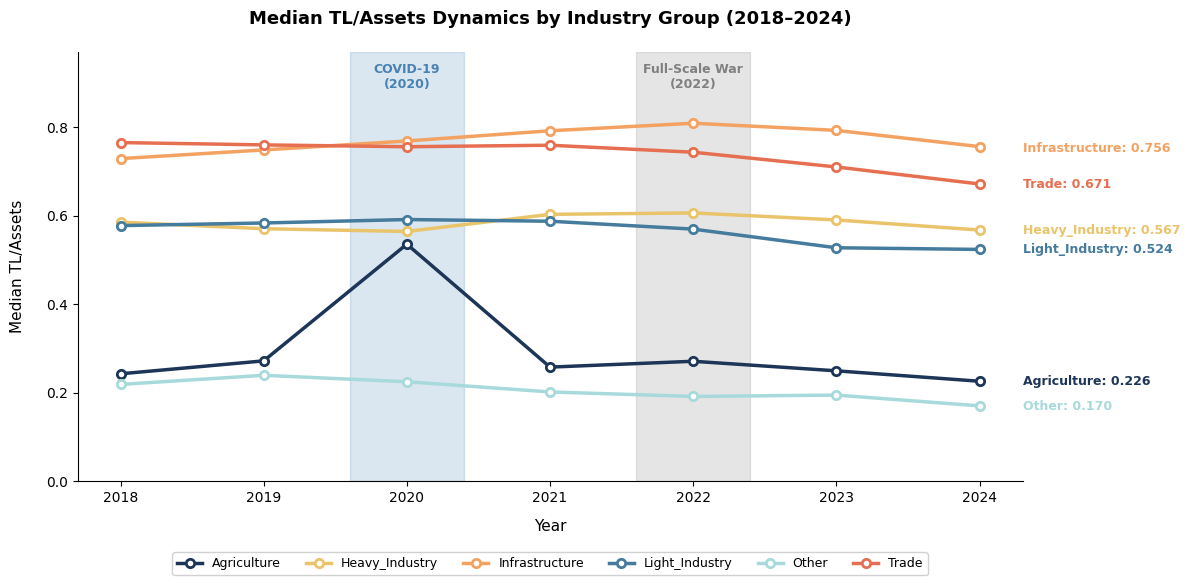

In [1659]:
y_max   = df_clean.groupby(['Industry_Group', 'Year'])['TL_Assets'].median().max()
offsets = {'Infrastructure': -0.005, 'Other': 0.00}

fig, ax = plt.subplots(figsize=(12, 6))
for industry in industries:
    yearly = df_clean[df_clean['Industry_Group'] == industry].groupby('Year')['TL_Assets'].median()
    ax.plot(yearly.index.astype(str), yearly.values, color=COLOR_MAP[industry], linewidth=2.5,
            marker='o', markersize=6, markerfacecolor='white',
            markeredgecolor=COLOR_MAP[industry], markeredgewidth=2, label=industry)
    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(years) - 0.7, last_y, f'{industry}: {yearly.values[-1]:.3f}',
            va='center', ha='left', fontsize=9, color=COLOR_MAP[industry], fontweight='bold')

ax.axvspan(x_pos_int[2019] + 0.6, x_pos_int[2020] + 0.4, alpha=0.2, color='steelblue')
ax.axvspan(x_pos_int[2021] + 0.6, x_pos_int[2022] + 0.4, alpha=0.2, color='gray')
ax.text(x_pos_int[2020], y_max * 1.1, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos_int[2022], y_max * 1.1, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_ylim(0, y_max * 1.2)
ax.set_title('Median TL/Assets Dynamics by Industry Group (2018–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Median TL/Assets', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False); plt.tight_layout(); plt.show()

### 6.10 AP/Assets quartile analysis

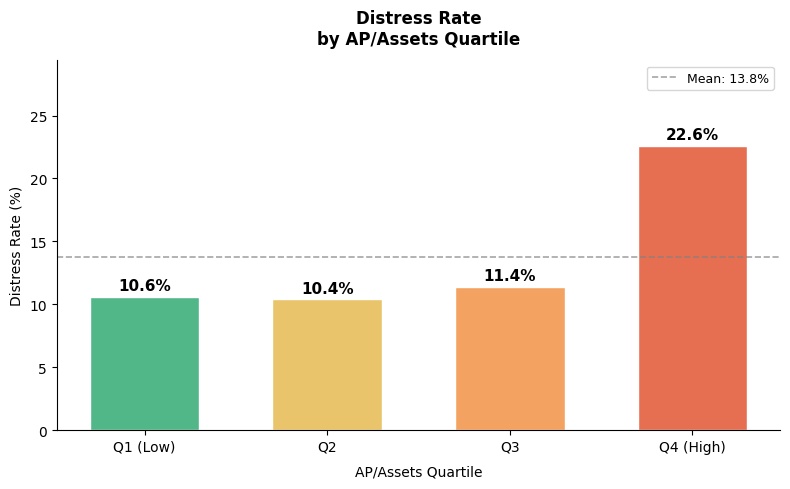

In [1660]:
# Assign AP/Assets quartiles
ana['AP_quartile'] = pd.qcut(ana['AP_Assets'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

comparison = ana.groupby('AP_quartile', observed=True).agg(
    N=('Firm ID', 'count'), Median_ROA=('ROA', 'median'),
    Distress_Rate=('Financial_Distress', 'mean'), Has_Debt=('Has_Debt', 'mean'),
    Median_AP_Assets=('AP_Assets', 'median')
).round(4)
comparison['Distress_Rate'] = (comparison['Distress_Rate'] * 100).round(1)
comparison['Has_Debt']      = (comparison['Has_Debt'] * 100).round(1)

industry_quartile = (
    ana.groupby(['Industry_Group', 'AP_quartile'], observed=True)['Financial_Distress']
    .mean().mul(100).round(1).unstack('AP_quartile')
)

quartiles = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
colors_q  = ['#52b788', '#e9c46a', '#f4a261', '#e76f51']
distress_by_q = comparison['Distress_Rate']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quartiles, distress_by_q.values, color=colors_q, edgecolor='white', width=0.6)
for bar, val in zip(bars, distress_by_q.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(y=distress_by_q.mean(), color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Mean: {distress_by_q.mean():.1f}%')
ax.set_title('Distress Rate\nby AP/Assets Quartile', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Distress Rate (%)', fontsize=10); ax.set_xlabel('AP/Assets Quartile', fontsize=10, labelpad=8)
ax.set_ylim(0, distress_by_q.max() * 1.3)
ax.spines[['top', 'right']].set_visible(False); ax.legend(fontsize=9); ax.grid(False)
plt.tight_layout(); plt.show()

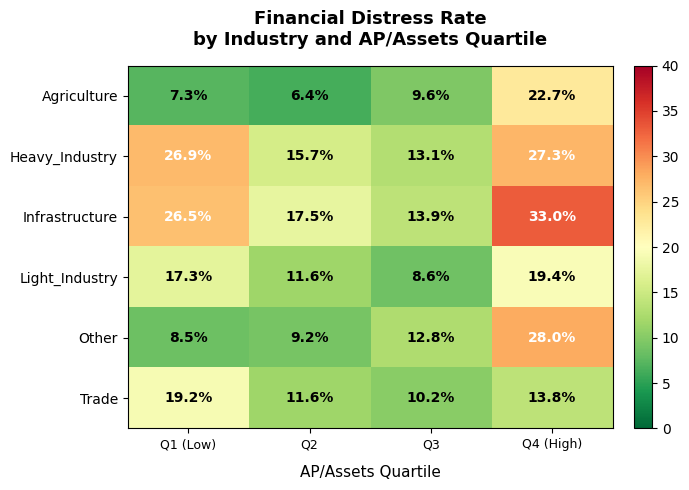

In [1661]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(industry_quartile.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=40)
ax.set_xticks(range(4)); ax.set_yticks(range(len(industry_quartile)))
ax.set_xticklabels(quartiles, fontsize=9); ax.set_yticklabels(industry_quartile.index, fontsize=10)
for i in range(len(industry_quartile)):
    for j in range(4):
        val = industry_quartile.values[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if val > 25 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xlabel('AP/Assets Quartile', fontsize=11, labelpad=10)
ax.set_title('Financial Distress Rate\nby Industry and AP/Assets Quartile', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

## **7. Solvency**

### 7.1 Interest coverage categories

In [1662]:
df_ic = df_clean[df_clean['Financial Expenses'] > 0].copy()

print("=" * 65); print("INTEREST COVERAGE ANALYSIS"); print("=" * 65)
print(f"Total observations           : {len(df_clean):,}")
print(f"With Financial Expenses > 0  : {len(df_ic):,}  ({len(df_ic)/len(df_clean)*100:.1f}%)")
print("\nIC categories:")
for label, cond in [('IC > 3  (comfortable)', df_ic['IC_Ratio'] > 3),
                     ('IC 1-3  (adequate)',   (df_ic['IC_Ratio'] > 1) & (df_ic['IC_Ratio'] <= 3)),
                     ('IC 0-1  (at risk)',    (df_ic['IC_Ratio'] > 0) & (df_ic['IC_Ratio'] <= 1)),
                     ('IC < 0  (critical)',   df_ic['IC_Ratio'] < 0)]:
    n = cond.sum(); print(f"  {label:<30} {n:>6,}  ({n/len(df_ic)*100:.1f}%)")

INTEREST COVERAGE ANALYSIS
Total observations           : 81,269
With Financial Expenses > 0  : 32,550  (40.1%)

IC categories:
  IC > 3  (comfortable)          16,255  (49.9%)
  IC 1-3  (adequate)              6,465  (19.9%)
  IC 0-1  (at risk)               2,406  (7.4%)
  IC < 0  (critical)              7,353  (22.6%)


### 7.2 Interest coverage categories dynamics

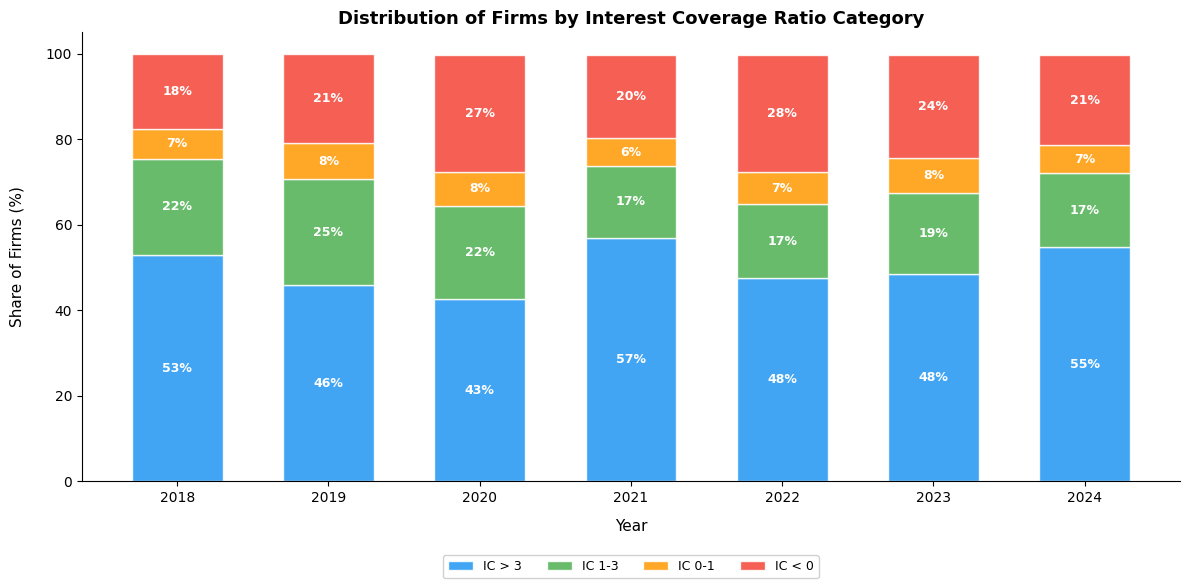

In [1663]:
yearly_cats = df_ic.groupby('Year').apply(lambda x: pd.Series({
    'IC > 3' : (x['IC_Ratio'] > 3).mean() * 100,
    'IC 1-3' : ((x['IC_Ratio'] > 1) & (x['IC_Ratio'] <= 3)).mean() * 100,
    'IC 0-1' : ((x['IC_Ratio'] > 0) & (x['IC_Ratio'] <= 1)).mean() * 100,
    'IC < 0' : (x['IC_Ratio'] < 0).mean() * 100,
})).round(1)
colors_cat = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(12, 6))
left = np.zeros(len(yearly_cats))
for col, color in zip(yearly_cats.columns, colors_cat):
    vals = yearly_cats[col].values
    bars = ax.bar(yearly_cats.index.astype(str), vals, bottom=left, color=color,
                  edgecolor='white', label=col, width=0.6, alpha=0.85)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 6:
            ax.text(bar.get_x() + bar.get_width()/2, left[i] + val/2, f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    left += vals

ax.set_title('Distribution of Firms by Interest Coverage Ratio Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Share of Firms (%)', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, framealpha=0.9)
ax.grid(False); plt.tight_layout(); plt.show()

### 7.3 Interest coverage < 1 share by industry and year

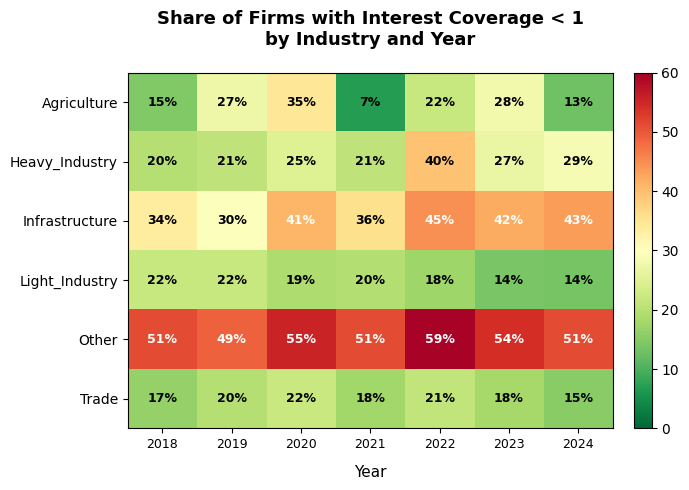

In [1664]:
heatmap_ic = (
    df_ic.groupby(['Industry_Group', 'Year'])
    .apply(lambda x: (x['IC_Ratio'] < 1).mean() * 100).unstack('Year').round(1)
)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heatmap_ic.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=60)
ax.set_xticks(range(len(heatmap_ic.columns))); ax.set_yticks(range(len(heatmap_ic.index)))
ax.set_xticklabels(heatmap_ic.columns, fontsize=9); ax.set_yticklabels(heatmap_ic.index, fontsize=10)
ax.set_xlabel('Year', fontsize=11, labelpad=10)
for i in range(len(heatmap_ic.index)):
    for j in range(len(heatmap_ic.columns)):
        val = heatmap_ic.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if val > 40 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Share of Firms with Interest Coverage < 1\nby Industry and Year', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()

## **8. Activity**

### 8.1 Payables Turnover distress and non-distress analysis

In [1665]:
print("=" * 65); print("PAYABLES TURNOVER ANALYSIS"); print("=" * 65)
pt_result = mw_stats(ana, 'Payables_Turnover', 'Payables Turnover')
# ind_pt is computed here and reused in the chart below
ind_pt = (ana.groupby('Industry_Group')['Payables_Turnover']
          .agg(Median='median',
               Non_D   =lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 0].median(),
               Distress=lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 1].median())
          .round(3).sort_values('Median', ascending=False))

PAYABLES TURNOVER ANALYSIS

Payables Turnover:
  Median Non-Distress :   7.6464
  Median Distress     :   1.2806
  Difference          :   6.3658
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.3063  medium


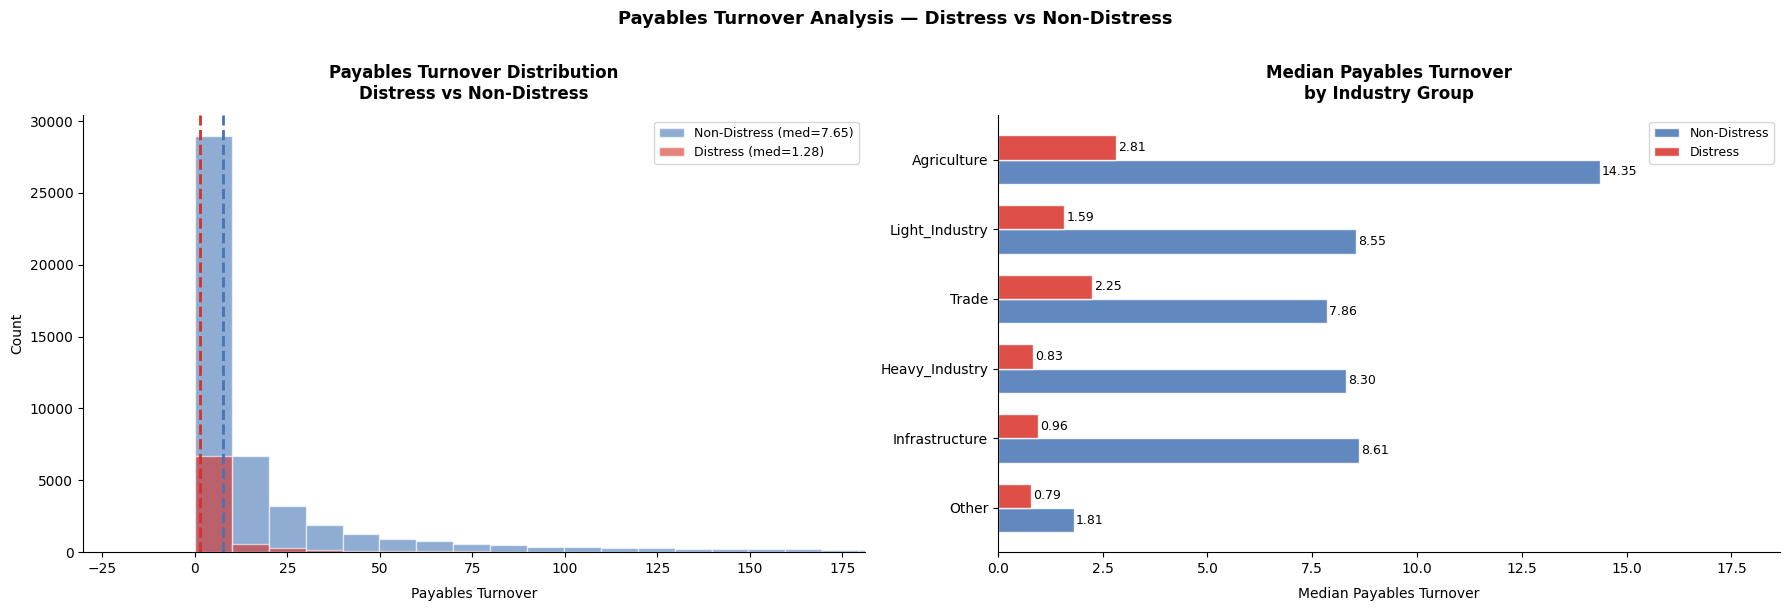

In [1666]:
colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}
industries   = sorted(ana['Industry_Group'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ax1, ax2  = axes

# Distribution
all_data = ana['Payables_Turnover'].dropna()
p10_h, p90_h = all_data.quantile(0.10), all_data.quantile(0.90)
m = (p90_h - p10_h) * 0.2
for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Payables_Turnover'].dropna()
    ax1.hist(data, bins=50, color=colors_group[group], alpha=0.6, edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.2f})")
    ax1.axvline(data.median(), color=colors_group[group], linewidth=2, linestyle='--')
ax1.set_xlim(p10_h - m, p90_h + m)
ax1.set_title('Payables Turnover Distribution\nDistress vs Non-Distress', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Payables Turnover', fontsize=10, labelpad=8); ax1.set_ylabel('Count', fontsize=10)
ax1.legend(fontsize=9); ax1.spines[['top', 'right']].set_visible(False); ax1.grid(False)

# By industry
ind_sorted = ind_pt.sort_values('Median', ascending=True)
y, width   = np.arange(len(ind_sorted)), 0.35
bars1 = ax2.barh(y - width/2, ind_sorted['Non_D'],    height=width, color=colors_group[0], edgecolor='white', alpha=0.85, label='Non-Distress')
bars2 = ax2.barh(y + width/2, ind_sorted['Distress'], height=width, color=colors_group[1], edgecolor='white', alpha=0.85, label='Distress')
for bar, val in zip(bars1, ind_sorted['Non_D']):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha='left', fontsize=9)
for bar, val in zip(bars2, ind_sorted['Distress']):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha='left', fontsize=9)
ax2.set_yticks(y); ax2.set_yticklabels(ind_sorted.index, fontsize=10)
ax2.set_title('Median Payables Turnover\nby Industry Group', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Median Payables Turnover', fontsize=10, labelpad=8)
ax2.set_xlim(0, ind_sorted[['Non_D', 'Distress']].max().max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False); ax2.legend(fontsize=9); ax2.grid(False)

fig.suptitle('Payables Turnover Analysis — Distress vs Non-Distress', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 8.2 Median Payables Turnover dynamics by industry

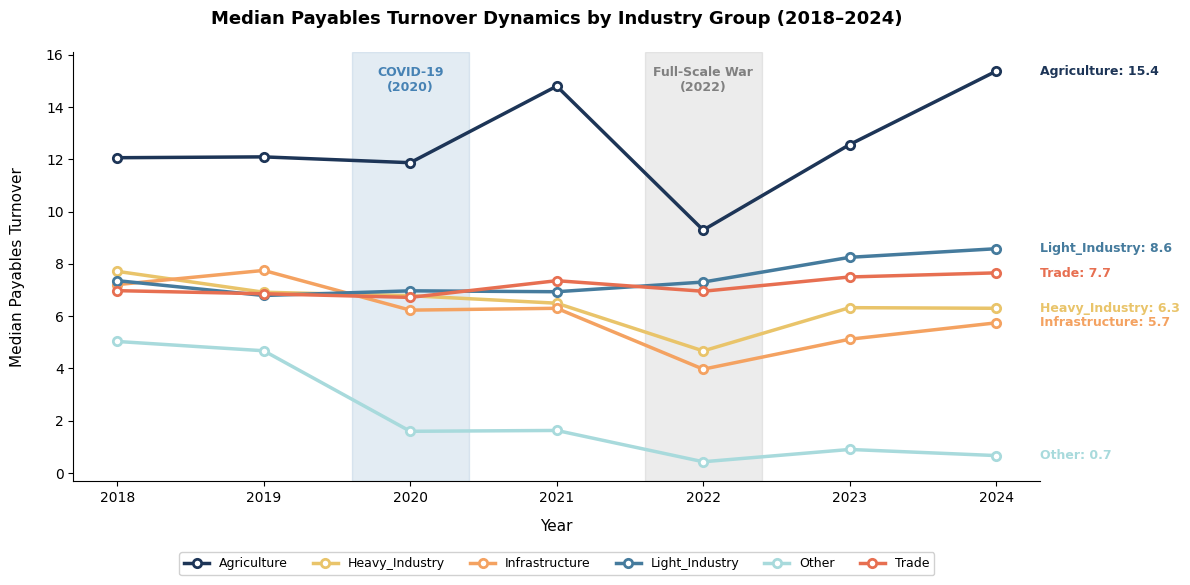

In [1667]:
y_max = df_clean.groupby(['Industry_Group', 'Year'])['Payables_Turnover'].median().max()

fig, ax = plt.subplots(figsize=(12, 6))
for industry in industries:
    yearly = df_clean[df_clean['Industry_Group'] == industry].groupby('Year')['Payables_Turnover'].median()
    ax.plot(yearly.index.astype(str), yearly.values, color=COLOR_MAP[industry], linewidth=2.5,
            marker='o', markersize=6, markerfacecolor='white',
            markeredgecolor=COLOR_MAP[industry], markeredgewidth=2, label=industry)
    ax.text(len(years) - 0.7, yearly.values[-1], f'{industry}: {yearly.values[-1]:.1f}',
            va='center', ha='left', fontsize=9, color=COLOR_MAP[industry], fontweight='bold')

ax.axvspan(x_pos_int[2019] + 0.6, x_pos_int[2020] + 0.4, alpha=0.15, color='steelblue')
ax.axvspan(x_pos_int[2021] + 0.6, x_pos_int[2022] + 0.4, alpha=0.15, color='gray')
ax.text(x_pos_int[2020], y_max * 0.95, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos_int[2022], y_max * 0.95, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Median Payables Turnover Dynamics by Industry Group (2018–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Median Payables Turnover', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False); plt.tight_layout(); plt.show()

### 8.3 Asset Turnover distress and non-distress analysis

In [1668]:
print("=" * 65); print("ASSET TURNOVER ANALYSIS"); print("=" * 65)
at_result = mw_stats(ana, 'Asset_Turnover', 'Asset Turnover')
# ind_at computed here and reused below
ind_at = (ana.groupby('Industry_Group')['Asset_Turnover']
          .agg(Median='median',
               Non_D   =lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 0].median(),
               Distress=lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 1].median())
          .round(3).sort_values('Median', ascending=False))

ASSET TURNOVER ANALYSIS

Asset Turnover:
  Median Non-Distress :   0.7200
  Median Distress     :   0.2574
  Difference          :   0.4626
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.2210  small


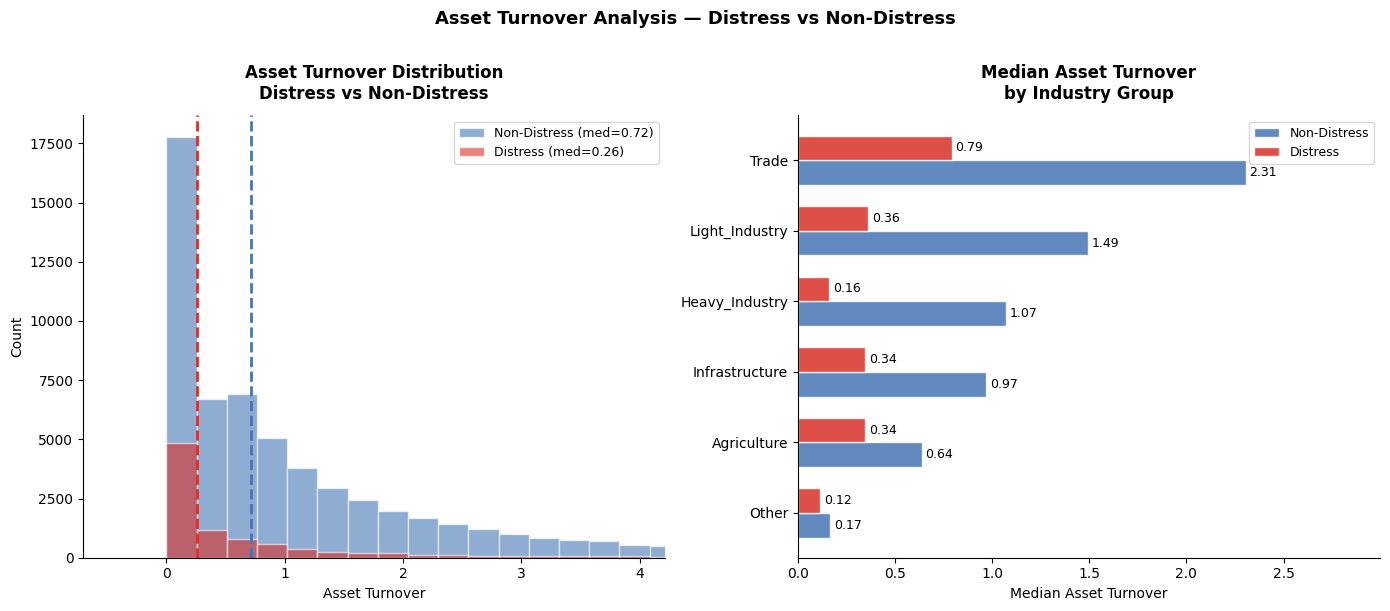

In [1669]:
colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1, ax2  = axes

all_data = ana['Asset_Turnover'].dropna()
p10_h, p90_h = all_data.quantile(0.10), all_data.quantile(0.90)
m = (p90_h - p10_h) * 0.2
for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Asset_Turnover'].dropna()
    ax1.hist(data, bins=50, color=colors_group[group], alpha=0.6, edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.2f})")
    ax1.axvline(data.median(), color=colors_group[group], linewidth=2, linestyle='--')
ax1.set_xlim(p10_h - m, p90_h + m)
ax1.set_title('Asset Turnover Distribution\nDistress vs Non-Distress', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Asset Turnover', fontsize=10); ax1.set_ylabel('Count', fontsize=10)
ax1.legend(fontsize=9); ax1.spines[['top', 'right']].set_visible(False); ax1.grid(False)

ind_sorted = ind_at.sort_values('Median', ascending=True)
y, width   = np.arange(len(ind_sorted)), 0.35
bars1 = ax2.barh(y - width/2, ind_sorted['Non_D'],    height=width, color=colors_group[0], edgecolor='white', alpha=0.85, label='Non-Distress')
bars2 = ax2.barh(y + width/2, ind_sorted['Distress'], height=width, color=colors_group[1], edgecolor='white', alpha=0.85, label='Distress')
for bar, val in zip(bars1, ind_sorted['Non_D']):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha='left', fontsize=9)
for bar, val in zip(bars2, ind_sorted['Distress']):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha='left', fontsize=9)
ax2.set_yticks(y); ax2.set_yticklabels(ind_sorted.index, fontsize=10)
ax2.set_title('Median Asset Turnover\nby Industry Group', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Median Asset Turnover', fontsize=10)
ax2.set_xlim(0, ind_sorted[['Non_D', 'Distress']].max().max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False); ax2.legend(fontsize=9); ax2.grid(False)

fig.suptitle('Asset Turnover Analysis — Distress vs Non-Distress', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 8.4 Median Asset Turnover dynamics by industry

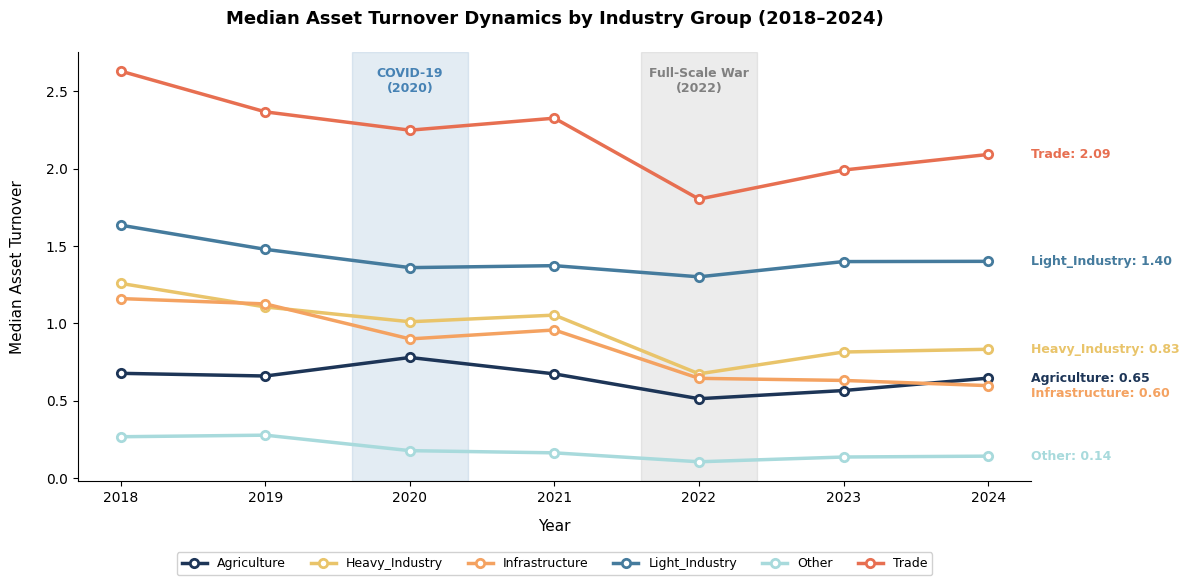

In [1670]:
y_max = df_clean.groupby(['Industry_Group', 'Year'])['Asset_Turnover'].median().max()
offsets = {'Infrastructure': -0.05}

fig, ax = plt.subplots(figsize=(12, 6))
for industry in industries:
    yearly = df_clean[df_clean['Industry_Group'] == industry].groupby('Year')['Asset_Turnover'].median()
    ax.plot(yearly.index.astype(str), yearly.values, color=COLOR_MAP[industry], linewidth=2.5,
            marker='o', markersize=6, markerfacecolor='white',
            markeredgecolor=COLOR_MAP[industry], markeredgewidth=2, label=industry)
    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(years) - 0.7, last_y, f'{industry}: {yearly.values[-1]:.2f}',
            va='center', ha='left', fontsize=9, color=COLOR_MAP[industry], fontweight='bold')

ax.axvspan(x_pos_int[2019] + 0.6, x_pos_int[2020] + 0.4, alpha=0.15, color='steelblue')
ax.axvspan(x_pos_int[2021] + 0.6, x_pos_int[2022] + 0.4, alpha=0.15, color='gray')
ax.text(x_pos_int[2020], y_max * 0.95, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos_int[2022], y_max * 0.95, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_title('Median Asset Turnover Dynamics by Industry Group (2018–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Median Asset Turnover', fontsize=11, labelpad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.grid(False); plt.tight_layout(); plt.show()

## **9. Investment Opportunities**

### 9.1 Investment Opportunities dynamics by industry

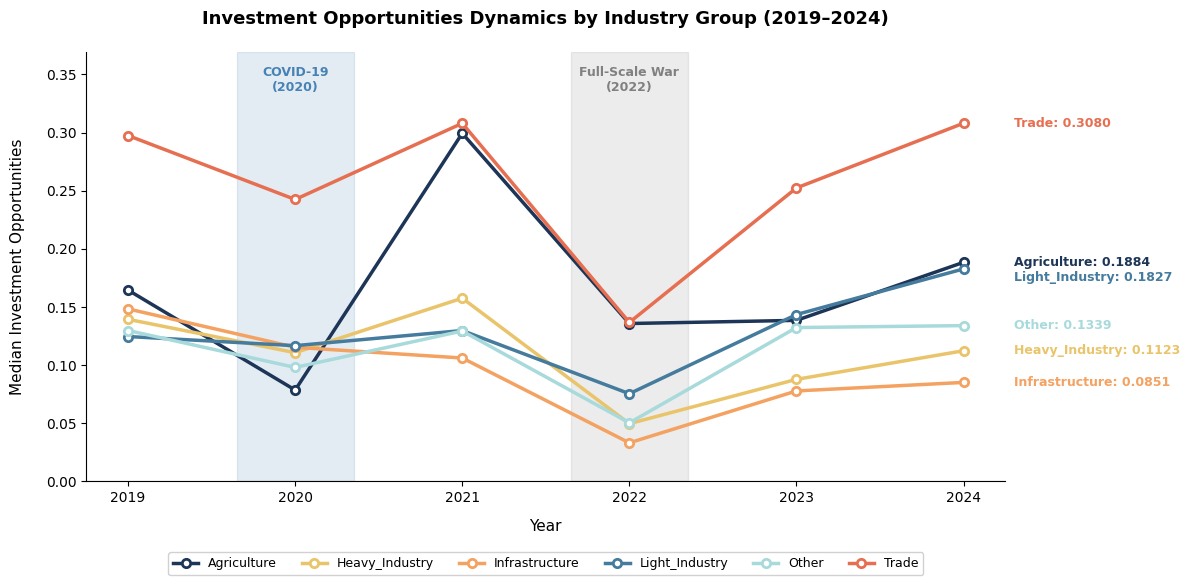

In [1671]:
y_max   = df_clean.groupby(['Industry_Group', 'Year'])['Investment_Opportunities'].median().max()
offsets = {'Light_Industry': -0.007}

fig, ax = plt.subplots(figsize=(12, 6))
for industry in industries:
    yearly = df_clean[df_clean['Industry_Group'] == industry].groupby('Year')['Investment_Opportunities'].median()
    ax.plot(yearly.index.astype(str), yearly.values, color=COLOR_MAP[industry], linewidth=2.5,
            marker='o', markersize=6, markerfacecolor='white',
            markeredgecolor=COLOR_MAP[industry], markeredgewidth=2, label=industry)
    last_y = yearly.values[-1] + offsets.get(industry, 0)
    ax.text(len(yearly) - 0.7, last_y, f'{industry}: {yearly.values[-1]:.4f}',
            va='center', ha='left', fontsize=9, color=COLOR_MAP[industry], fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
ax.axvspan(x_pos_int[2019] + 0.65, x_pos_int[2020] + 0.35, alpha=0.15, color='steelblue')
ax.axvspan(x_pos_int[2021] + 0.65, x_pos_int[2022] + 0.35, alpha=0.15, color='gray')
ax.text(x_pos_int[2020], y_max * 1.09, 'COVID-19\n(2020)', ha='center', fontsize=9, color='steelblue', fontweight='bold')
ax.text(x_pos_int[2022], y_max * 1.09, 'Full-Scale War\n(2022)', ha='center', fontsize=9, color='gray', fontweight='bold')

ax.set_ylim(0, y_max * 1.2)
ax.set_title('Investment Opportunities Dynamics by Industry Group (2019–2024)', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11, labelpad=10); ax.set_ylabel('Median Investment Opportunities', fontsize=11, labelpad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9, ncol=6, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 9.2 Investment Opportunities distress and non-distress analysis

In [1672]:
print("=" * 65); print("INVESTMENT OPPORTUNITIES — Distress vs Non-Distress"); print("=" * 65)
io_result = mw_stats(ana, 'Investment_Opportunities', 'Investment Opportunities')

ind_io = (ana.groupby('Industry_Group')['Investment_Opportunities']
          .agg(Non_D   =lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 0].median(),
               Distress=lambda x: x[ana.loc[x.index, 'Financial_Distress'] == 1].median())
          .round(4).sort_values('Non_D', ascending=True))

INVESTMENT OPPORTUNITIES — Distress vs Non-Distress

Investment Opportunities:
  Median Non-Distress :   0.1661
  Median Distress     :   0.0121
  Difference          :   0.1540
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.3167  medium


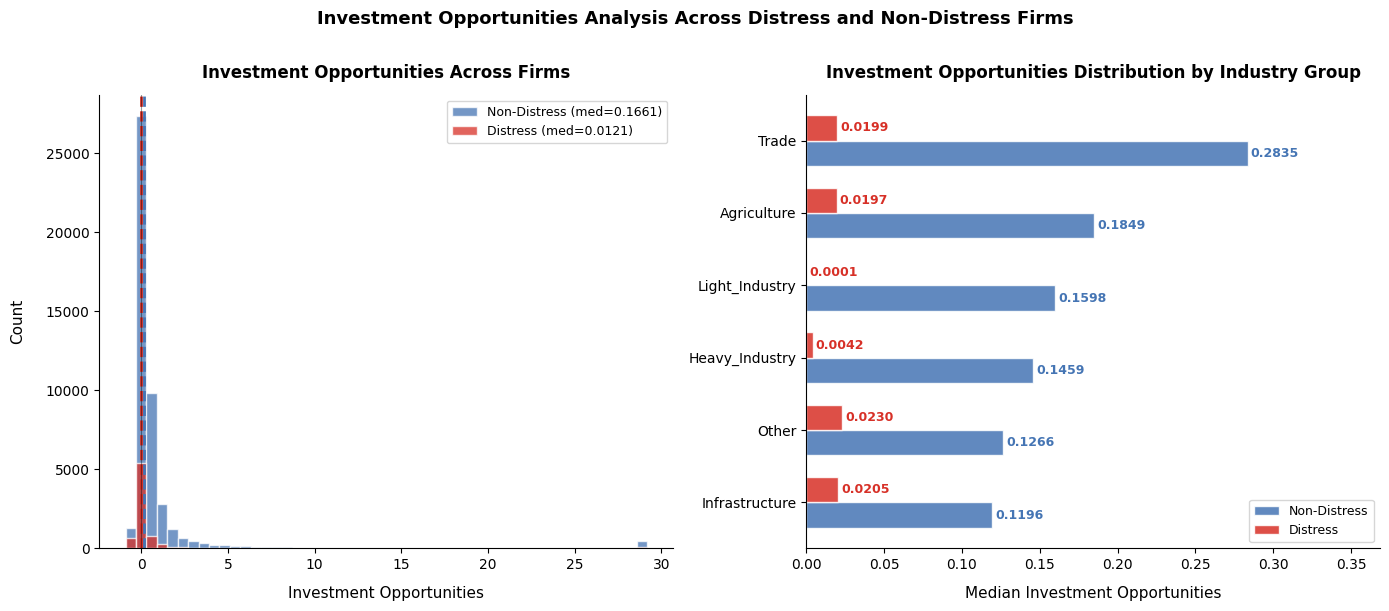

In [1673]:
colors_group = {0: '#4575b4', 1: '#d73027'}
labels_group = {0: 'Non-Distress', 1: 'Distress'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1, ax2  = axes

# Distribution
for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Investment_Opportunities'].dropna()
    ax1.hist(data, bins=50, color=colors_group[group], alpha=0.75, edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.4f})")
    ax1.axvline(data.median(), color=colors_group[group], linewidth=2, linestyle='--')
ax1.axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
ax1.set_title('Investment Opportunities Across Firms', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Investment Opportunities', fontsize=11, labelpad=10); ax1.set_ylabel('Count', fontsize=11, labelpad=15)
ax1.legend(fontsize=9); ax1.spines[['top', 'right']].set_visible(False); ax1.grid(False)

# By industry
y, width = np.arange(len(ind_io)), 0.35
bars1 = ax2.barh(y - width/2, ind_io['Non_D'],    height=width, color=colors_group[0], edgecolor='white', alpha=0.85, label='Non-Distress')
bars2 = ax2.barh(y + width/2, ind_io['Distress'], height=width, color=colors_group[1], edgecolor='white', alpha=0.85, label='Distress')
for bar, val in zip(bars1, ind_io['Non_D']):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', ha='left', fontsize=9, color='#4575b4', fontweight='bold')
for bar, val in zip(bars2, ind_io['Distress']):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', ha='left', fontsize=9, color='#d73027', fontweight='bold')
ax2.set_yticks(y); ax2.set_yticklabels(ind_io.index, fontsize=10)
ax2.set_title('Investment Opportunities Distribution by Industry Group', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Median Investment Opportunities', fontsize=11, labelpad=10)
ax2.set_xlim(0, ind_io.max().max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False); ax2.legend(fontsize=9, loc='lower right'); ax2.grid(False)

fig.suptitle('Investment Opportunities Analysis Across Distress and Non-Distress Firms', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## **10. Size and Age**

### 10.1 Log(Assets) distress and non-distress analysis

In [1674]:
print("=" * 65); print("LOG(ASSETS) vs DISTRESS"); print("=" * 65)
size_result = mw_stats(ana, 'Log_Assets', 'Log(Assets)')

d0 = ana[ana['Financial_Distress'] == 0]['Log_Assets'].dropna()
d1 = ana[ana['Financial_Distress'] == 1]['Log_Assets'].dropna()
print(f"  Median Non-Distress assets : {np.exp(d0.median()):,.0f}")
print(f"  Median Distress assets     : {np.exp(d1.median()):,.0f}")

ana['Size_quintile'] = pd.qcut(ana['Log_Assets'], q=5,
    labels=['Q1 (Smallest)', 'Q2', 'Q3', 'Q4', 'Q5 (Largest)'])
size_distress = (ana.groupby('Size_quintile', observed=True)['Financial_Distress']
                 .agg(N='count', Distress_Rate='mean')
                 .assign(Distress_Rate=lambda x: (x['Distress_Rate'] * 100).round(1)))
print("\nDistress rate by Size Quintile:"); print(size_distress.to_string())

LOG(ASSETS) vs DISTRESS

Log(Assets):
  Median Non-Distress :  11.2123
  Median Distress     :  10.2542
  Difference          :   0.9581
  Mann-Whitney p      : 0.0000  ***
  Effect size (r)     : 0.2052  small
  Median Non-Distress assets : 74,035
  Median Distress assets     : 28,401

Distress rate by Size Quintile:
                   N  Distress_Rate
Size_quintile                      
Q1 (Smallest)  14070           22.3
Q2             14070           14.6
Q3             14069           11.3
Q4             14070            9.5
Q5 (Largest)   14070           11.0


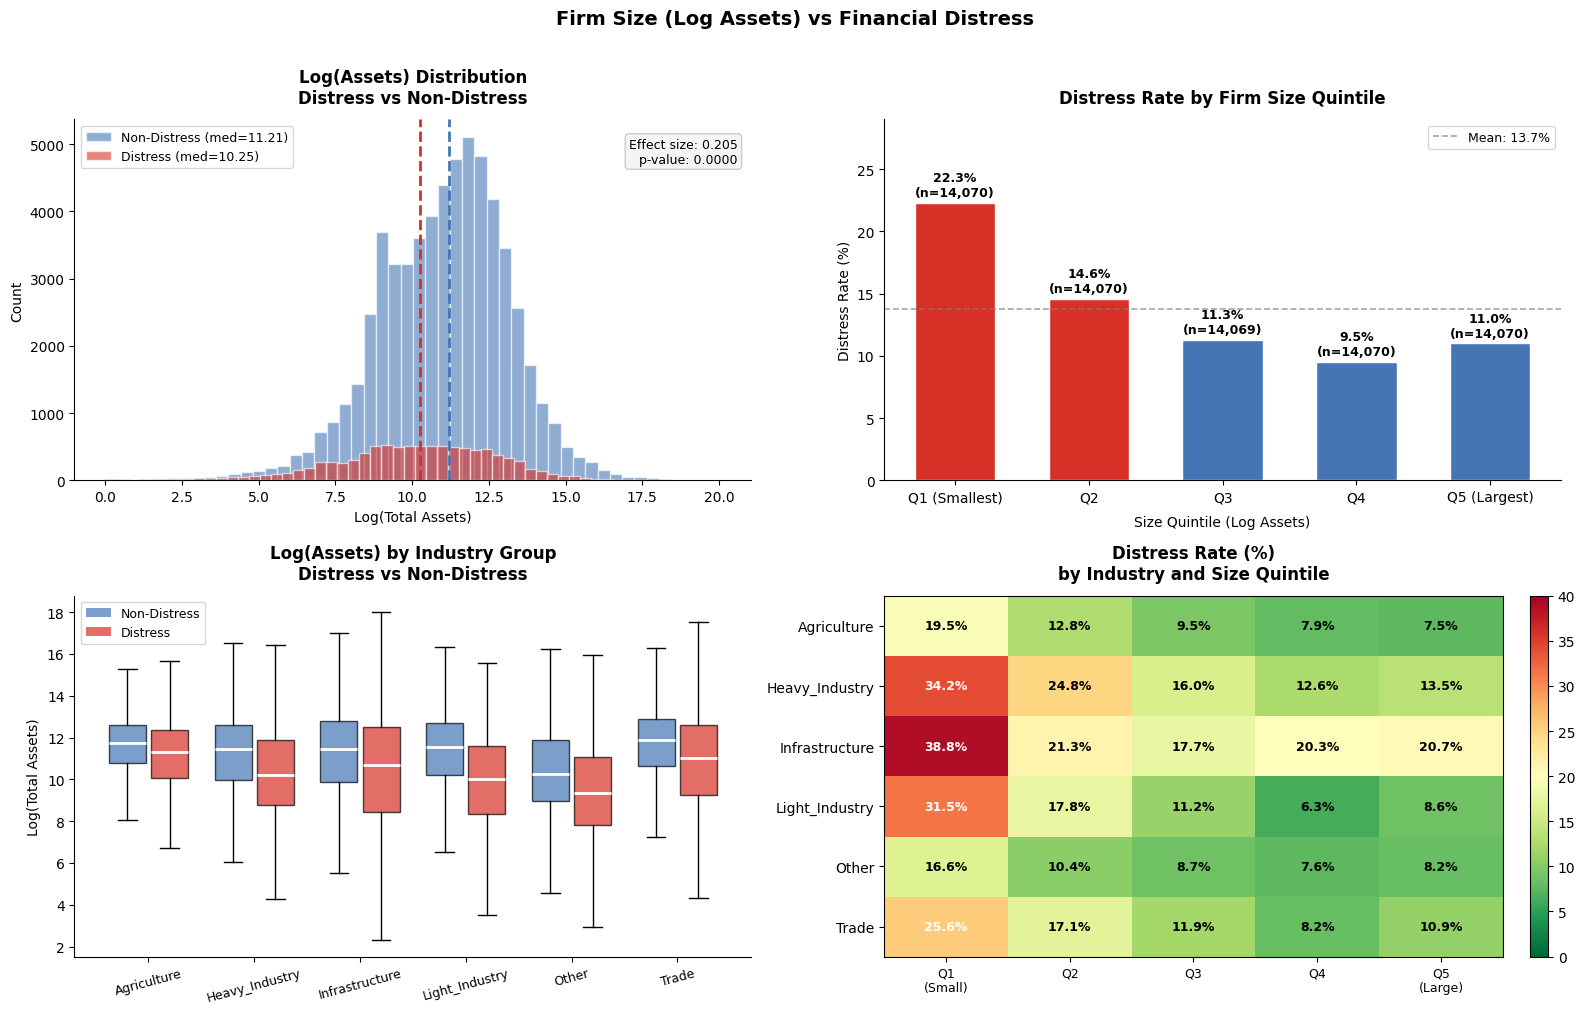

In [1675]:
stat_mw, p_val = stats.mannwhitneyu(d0, d1, alternative='two-sided')
effect         = abs(1 - (2 * stat_mw) / (len(d0) * len(d1)))
industries     = sorted(ana['Industry_Group'].dropna().unique())
colors_group   = {0: '#4575b4', 1: '#d73027'}
labels_group   = {0: 'Non-Distress', 1: 'Distress'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution
ax1 = axes[0, 0]
for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Log_Assets'].dropna()
    ax1.hist(data, bins=50, color=colors_group[group], alpha=0.6, edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.2f})")
    ax1.axvline(data.median(), color=colors_group[group], linewidth=2, linestyle='--')
ax1.set_title('Log(Assets) Distribution\nDistress vs Non-Distress', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Log(Total Assets)', fontsize=10); ax1.set_ylabel('Count', fontsize=10)
ax1.legend(fontsize=9); ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.98, 0.95, f'Effect size: {effect:.3f}\np-value: {p_val:.4f}', transform=ax1.transAxes,
         ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='#f5f5f5', edgecolor='#cccccc'))
ax1.grid(False)

# Distress rate by size quintile
ax2 = axes[0, 1]
colors_q = ['#d73027' if v > size_distress['Distress_Rate'].mean() else '#4575b4' for v in size_distress['Distress_Rate']]
bars = ax2.bar(size_distress.index.tolist(), size_distress['Distress_Rate'], color=colors_q, edgecolor='white', width=0.6)
for bar, val, n in zip(bars, size_distress['Distress_Rate'], size_distress['N']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%\n(n={n:,})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(y=size_distress['Distress_Rate'].mean(), color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Mean: {size_distress["Distress_Rate"].mean():.1f}%')
ax2.set_title('Distress Rate by Firm Size Quintile', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Distress Rate (%)', fontsize=10); ax2.set_xlabel('Size Quintile (Log Assets)', fontsize=10, labelpad=8)
ax2.set_ylim(0, size_distress['Distress_Rate'].max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False); ax2.legend(fontsize=9); ax2.grid(False)

# Boxplot by industry
ax3 = axes[1, 0]
positions_0 = np.arange(len(industries)) - 0.2
positions_1 = np.arange(len(industries)) + 0.2
data_0 = [ana[(ana['Industry_Group']==ind)&(ana['Financial_Distress']==0)]['Log_Assets'].dropna() for ind in industries]
data_1 = [ana[(ana['Industry_Group']==ind)&(ana['Financial_Distress']==1)]['Log_Assets'].dropna() for ind in industries]
bp0 = ax3.boxplot(data_0, positions=positions_0, widths=0.35, patch_artist=True, showfliers=False, medianprops=dict(color='white', linewidth=2))
bp1 = ax3.boxplot(data_1, positions=positions_1, widths=0.35, patch_artist=True, showfliers=False, medianprops=dict(color='white', linewidth=2))
for patch in bp0['boxes']: patch.set_facecolor(colors_group[0]); patch.set_alpha(0.7)
for patch in bp1['boxes']: patch.set_facecolor(colors_group[1]); patch.set_alpha(0.7)
ax3.set_xticks(np.arange(len(industries))); ax3.set_xticklabels(industries, rotation=15, fontsize=9)
ax3.set_title('Log(Assets) by Industry Group\nDistress vs Non-Distress', fontsize=12, fontweight='bold', pad=12)
ax3.set_ylabel('Log(Total Assets)', fontsize=10)
ax3.legend(handles=[Patch(facecolor=colors_group[g], alpha=0.7, label=labels_group[g]) for g in [0, 1]], fontsize=9)
ax3.spines[['top', 'right']].set_visible(False); ax3.grid(False)

# Heatmap by industry and size quintile
ax4 = axes[1, 1]
heatmap_size = (ana.groupby(['Industry_Group', 'Size_quintile'], observed=True)['Financial_Distress']
                .mean().mul(100).round(1).unstack('Size_quintile'))
im = ax4.imshow(heatmap_size.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=40)
ax4.set_xticks(range(5)); ax4.set_yticks(range(len(heatmap_size)))
ax4.set_xticklabels(['Q1\n(Small)', 'Q2', 'Q3', 'Q4', 'Q5\n(Large)'], fontsize=9)
ax4.set_yticklabels(heatmap_size.index, fontsize=10)
for i in range(len(heatmap_size)):
    for j in range(5):
        val = heatmap_size.values[i, j]
        ax4.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold',
                 color='white' if val > 25 else 'black')
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_title('Distress Rate (%)\nby Industry and Size Quintile', fontsize=12, fontweight='bold', pad=12)

fig.suptitle('Firm Size (Log Assets) vs Financial Distress', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 10.2 Firm Age distress and non-distress analysis

In [1676]:
print("=" * 65); print("FIRM AGE vs DISTRESS"); print("=" * 65)
age_result = mw_stats(ana, 'Firm Age', 'Firm Age')

ana['Age_group'] = pd.cut(ana['Firm Age'], bins=[0, 5, 10, 15, 20, 30, 100],
                           labels=['0-5 (Young)', '6-10', '11-15', '16-20', '21-30', '30+ (Mature)'])
age_distress = (ana.groupby('Age_group', observed=True)['Financial_Distress']
                .agg(N='count', Distress_Rate='mean')
                .assign(Distress_Rate=lambda x: (x['Distress_Rate'] * 100).round(1)))
print("\nDistress rate by Age Group:"); print(age_distress.to_string())

FIRM AGE vs DISTRESS

Firm Age:
  Median Non-Distress :  17.0000
  Median Distress     :  18.0000
  Difference          :  -1.0000
  Mann-Whitney p      : 0.0001  ***
  Effect size (r)     : 0.0247  small

Distress rate by Age Group:
                  N  Distress_Rate
Age_group                         
0-5 (Young)   11315           12.5
6-10          10234           14.9
11-15          9067           13.7
16-20         13083           12.9
21-30         24551           14.3
30+ (Mature)   2098           14.1


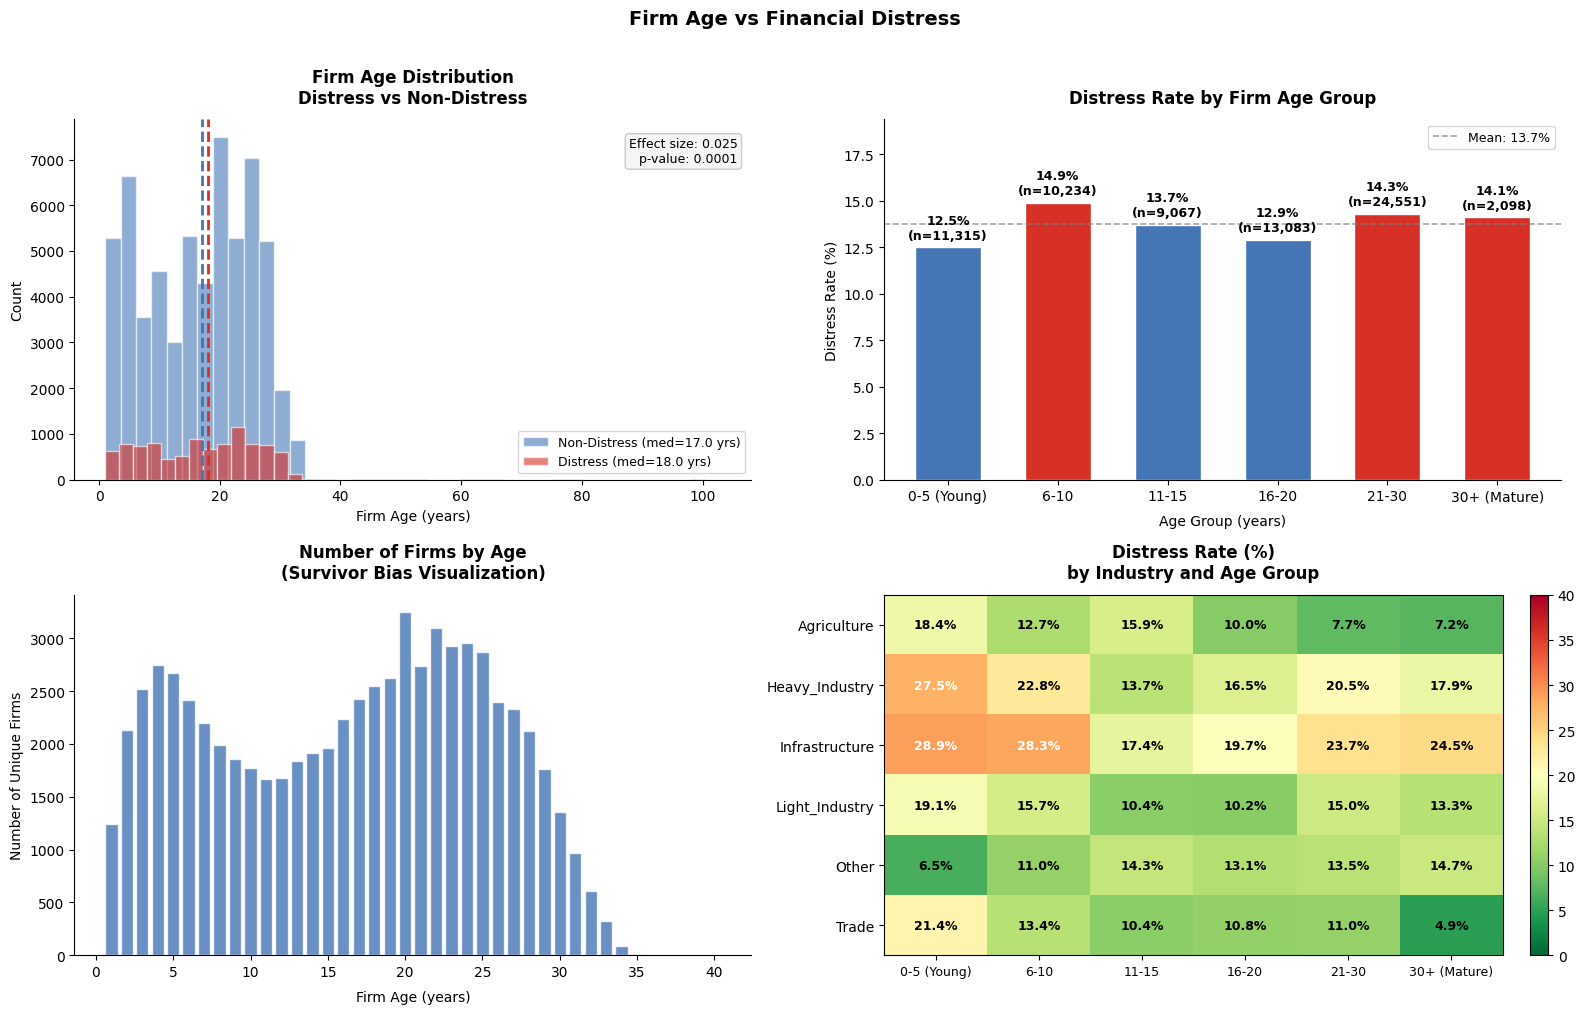

In [1677]:
d0_age = ana[ana['Financial_Distress'] == 0]['Firm Age'].dropna()
d1_age = ana[ana['Financial_Distress'] == 1]['Firm Age'].dropna()
stat_age, p_age = stats.mannwhitneyu(d0_age, d1_age, alternative='two-sided')
effect_age      = abs(1 - (2 * stat_age) / (len(d0_age) * len(d1_age)))
colors_group    = {0: '#4575b4', 1: '#d73027'}
labels_group    = {0: 'Non-Distress', 1: 'Distress'}

cohort = (ana.groupby('Firm Age')['Firm ID'].nunique().reset_index()
          .rename(columns={'Firm ID': 'N_Firms'}).sort_values('Firm Age'))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribution
ax1 = axes[0, 0]
for group in [0, 1]:
    data = ana[ana['Financial_Distress'] == group]['Firm Age'].dropna()
    ax1.hist(data, bins=40, color=colors_group[group], alpha=0.6, edgecolor='white',
             label=f"{labels_group[group]} (med={data.median():.1f} yrs)")
    ax1.axvline(data.median(), color=colors_group[group], linewidth=2, linestyle='--')
ax1.set_title('Firm Age Distribution\nDistress vs Non-Distress', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Firm Age (years)', fontsize=10); ax1.set_ylabel('Count', fontsize=10)
ax1.legend(fontsize=9); ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.98, 0.95, f'Effect size: {effect_age:.3f}\np-value: {p_age:.4f}', transform=ax1.transAxes,
         ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='#f5f5f5', edgecolor='#cccccc'))
ax1.grid(False)

# Distress rate by age group
ax2 = axes[0, 1]
colors_age = ['#d73027' if v > age_distress['Distress_Rate'].mean() else '#4575b4' for v in age_distress['Distress_Rate']]
bars = ax2.bar(age_distress.index.tolist(), age_distress['Distress_Rate'], color=colors_age, edgecolor='white', width=0.6)
for bar, val, n in zip(bars, age_distress['Distress_Rate'], age_distress['N']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%\n(n={n:,})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(y=age_distress['Distress_Rate'].mean(), color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Mean: {age_distress["Distress_Rate"].mean():.1f}%')
ax2.set_title('Distress Rate by Firm Age Group', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Distress Rate (%)', fontsize=10); ax2.set_xlabel('Age Group (years)', fontsize=10, labelpad=8)
ax2.set_ylim(0, age_distress['Distress_Rate'].max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False); ax2.legend(fontsize=9); ax2.grid(False)

# Survivor bias
ax3 = axes[1, 0]
cohort_plot = cohort[cohort['Firm Age'] <= 40]
ax3.bar(cohort_plot['Firm Age'], cohort_plot['N_Firms'], color='#4575b4', edgecolor='white', alpha=0.8, width=0.8)
ax3.set_title('Number of Firms by Age\n(Survivor Bias Visualization)', fontsize=12, fontweight='bold', pad=12)
ax3.set_xlabel('Firm Age (years)', fontsize=10, labelpad=8); ax3.set_ylabel('Number of Unique Firms', fontsize=10)
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(False)

# Heatmap by industry and age group
ax4 = axes[1, 1]
heatmap_age = (ana.groupby(['Industry_Group', 'Age_group'], observed=True)['Financial_Distress']
               .mean().mul(100).round(1).unstack('Age_group'))
im = ax4.imshow(heatmap_age.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=40)
ax4.set_xticks(range(len(heatmap_age.columns))); ax4.set_yticks(range(len(heatmap_age)))
ax4.set_xticklabels(heatmap_age.columns.tolist(), fontsize=9); ax4.set_yticklabels(heatmap_age.index, fontsize=10)
for i in range(len(heatmap_age)):
    for j in range(len(heatmap_age.columns)):
        val = heatmap_age.values[i, j]
        if not np.isnan(val):
            ax4.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold',
                     color='white' if val > 25 else 'black')
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
ax4.set_title('Distress Rate (%)\nby Industry and Age Group', fontsize=12, fontweight='bold', pad=12)

fig.suptitle('Firm Age vs Financial Distress', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## **11. Crisis Heterogeneity**

In [1678]:
# Add 3-period label to both datasets (2019, 2020, 2022 only)
for d in [df_clean, ana]:
    d['Period3'] = np.where(d['Year'] == 2019, 'Pre-Crisis\n(2019)',
                   np.where(d['Year'] == 2020, 'COVID-19\n(2020)',
                   np.where(d['Year'] == 2022, 'Full-Scale War\n(2022)', None)))

INDICATORS = {k: v for k, v in {
    'ROA'                    : 'ROA',
    'Current Ratio'          : 'Current_Ratio',
    'TL/Assets'              : 'TL_Assets',
    'AP/Assets'              : 'AP_Assets',
    'Asset Turnover'         : 'Asset_Turnover',
    'Payables Turnover'      : 'Payables_Turnover',
    'Interest Coverage'      : 'IC_Ratio',
    'Investment Opportunities': 'Investment_Opportunities',
}.items() if v in df_clean.columns}

PERIOD_COLS = ['Pre-Crisis\n(2019)', 'COVID-19\n(2020)', 'Full-Scale War\n(2022)']

# Compute median by period for all indicators
period_df = pd.DataFrame({
    name: df_clean[df_clean['Period3'].notna()].groupby('Period3')[col].median()
    for name, col in INDICATORS.items()
}).T.reindex(columns=PERIOD_COLS)

# Percentage change vs pre-crisis
changes_df = pd.DataFrame({
    col: ((period_df[col] - period_df[PERIOD_COLS[0]]) / period_df[PERIOD_COLS[0]].abs() * 100).round(1)
    for col in PERIOD_COLS[1:]
})

# Median by period for distress and non-distress groups
nd_df = pd.DataFrame({
    name: ana[(ana['Financial_Distress'] == 0) & ana['Period3'].notna()]
          .groupby('Period3')[col].median()
    for name, col in INDICATORS.items()
}).T.reindex(columns=PERIOD_COLS)

d_df = pd.DataFrame({
    name: ana[(ana['Financial_Distress'] == 1) & ana['Period3'].notna()]
          .groupby('Period3')[col].median()
    for name, col in INDICATORS.items()
}).T.reindex(columns=PERIOD_COLS)

industries_sorted = sorted(df_clean['Industry_Group'].dropna().unique())

### 11.1 Change in key indicators vs pre-crisis

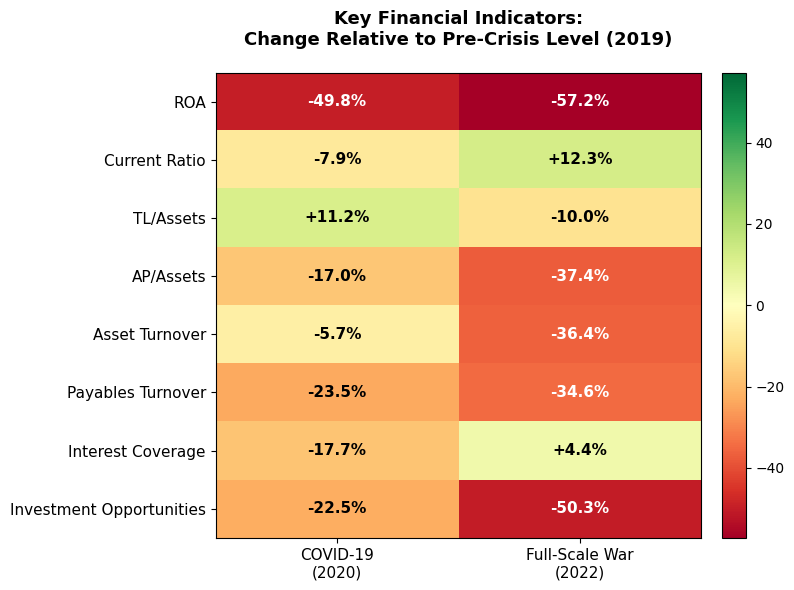

In [1679]:
fig, ax = plt.subplots(figsize=(8, 6))
change_data = changes_df.values.astype(float)
max_abs     = np.nanmax(np.abs(change_data))

im = ax.imshow(change_data, cmap='RdYlGn', aspect='auto', vmin=-max_abs, vmax=max_abs)
ax.set_xticks(range(2)); ax.set_yticks(range(len(changes_df)))
ax.set_xticklabels(['COVID-19\n(2020)', 'Full-Scale War\n(2022)'], fontsize=11)
ax.set_yticklabels(changes_df.index, fontsize=11)

for i in range(len(changes_df)):
    for j in range(2):
        val  = change_data[i, j]
        sign = '+' if val > 0 else ''
        ax.text(j, i, f'{sign}{val:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if abs(val) > max_abs * 0.6 else 'black')

plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
ax.set_title('Key Financial Indicators:\nChange Relative to Pre-Crisis Level (2019)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()

### 11.2 Non-distress and distress median by subperiods

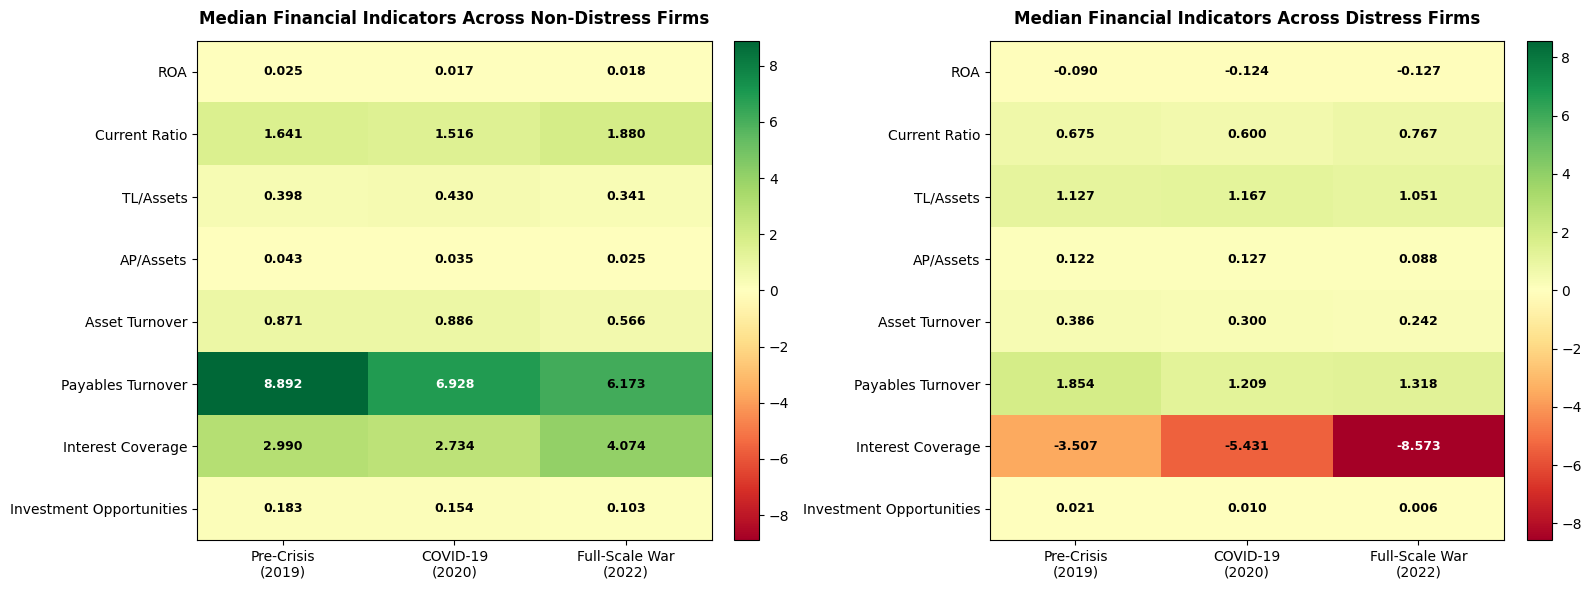

In [1680]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(axes, [nd_df, d_df],
    ['Median Financial Indicators Across Non-Distress Firms',
     'Median Financial Indicators Across Distress Firms']):

    plot_vals = data.values.astype(float)
    abs_max   = np.nanmax(np.abs(plot_vals))
    im = ax.imshow(plot_vals, cmap='RdYlGn', aspect='auto', vmin=-abs_max, vmax=abs_max)

    ax.set_xticks(range(3)); ax.set_yticks(range(len(data)))
    ax.set_xticklabels(PERIOD_COLS, fontsize=10); ax.set_yticklabels(data.index, fontsize=10)

    for i in range(len(data)):
        for j in range(3):
            val = plot_vals[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, fontweight='bold',
                    color='white' if abs(val) > abs_max * 0.7 else 'black')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

plt.tight_layout(); plt.show()

### 11.3 Change in indicators by industries and subperiods

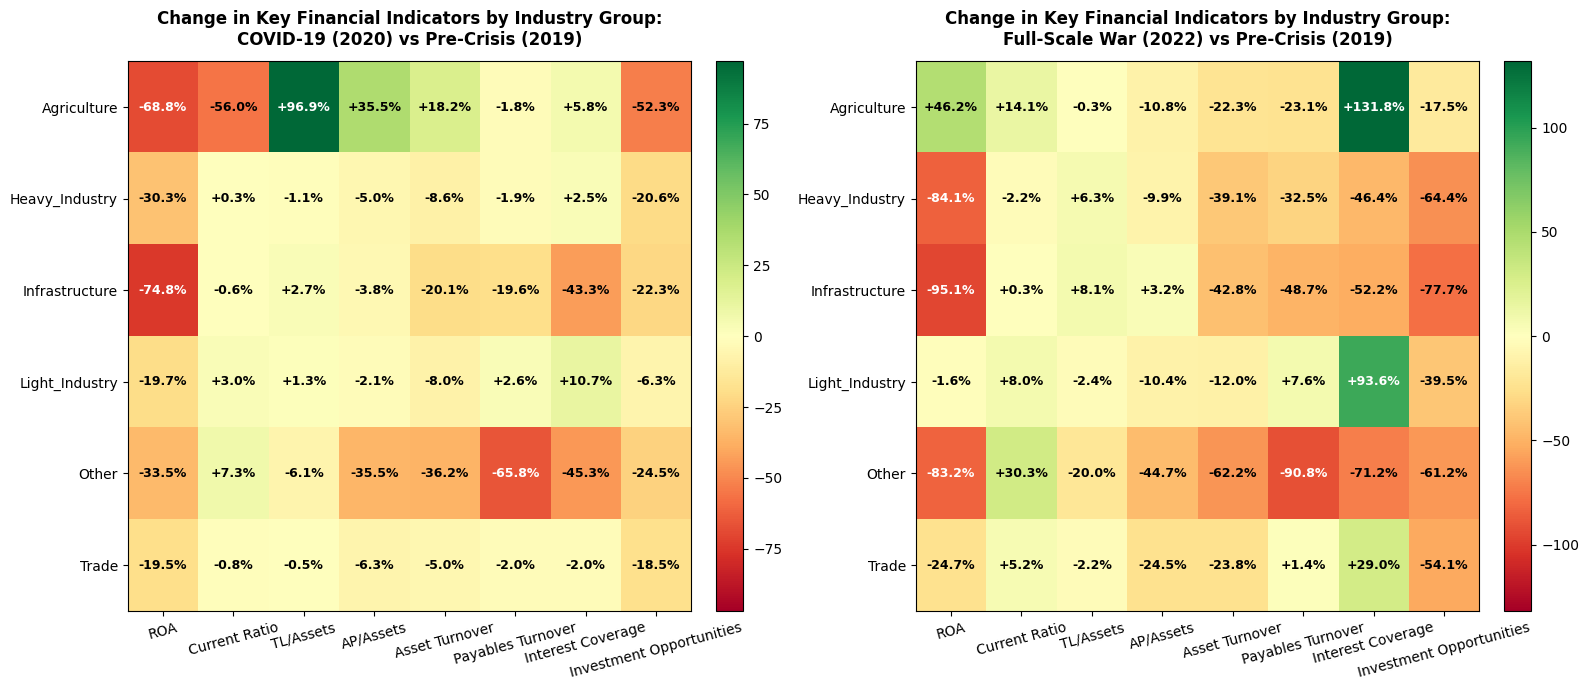

In [1681]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, period, title in zip(axes, [PERIOD_COLS[1], PERIOD_COLS[2]],
    ['COVID-19 (2020) vs Pre-Crisis (2019)',
     'Full-Scale War (2022) vs Pre-Crisis (2019)']):

    # Compute % change per industry for this crisis period
    change_matrix = pd.DataFrame(index=industries_sorted, columns=list(INDICATORS.keys()))
    for name, col in INDICATORS.items():
        pre  = df_clean[df_clean['Period3'] == PERIOD_COLS[0]].groupby('Industry_Group')[col].median()
        curr = df_clean[df_clean['Period3'] == period].groupby('Industry_Group')[col].median()
        change_matrix[name] = ((curr - pre) / pre.abs() * 100).round(1)

    change_data = change_matrix.values.astype(float)
    max_abs     = np.nanmax(np.abs(change_data))
    im = ax.imshow(change_data, cmap='RdYlGn', aspect='auto', vmin=-max_abs, vmax=max_abs)

    ax.set_xticks(range(len(INDICATORS))); ax.set_yticks(range(len(industries_sorted)))
    ax.set_xticklabels(list(INDICATORS.keys()), fontsize=10, rotation=15)
    ax.set_yticklabels(industries_sorted, fontsize=10)

    for i in range(len(industries_sorted)):
        for j in range(len(INDICATORS)):
            val  = change_data[i, j]
            sign = '+' if val > 0 else ''
            ax.text(j, i, f'{sign}{val:.1f}%', ha='center', va='center', fontsize=9, fontweight='bold',
                    color='white' if abs(val) > max_abs * 0.6 else 'black')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'Change in Key Financial Indicators by Industry Group:\n{title}',
                 fontsize=12, fontweight='bold', pad=12)

plt.tight_layout(); plt.show()